# Libraries

In [1]:
import sys
import os
import pandas as pd
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import proportion_confint

In [2]:
this_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(this_dir, os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
os.chdir(project_root)

In [3]:
from kg_rag.util import *

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [5]:
def parse_model_answer(answer):
    try:
        if isinstance(answer, str):
            json_match = re.search(r'\{.*\}', answer, re.DOTALL)
            if json_match:
                parsed = json.loads(json_match.group())
                if 'answer' in parsed:
                    return parsed['answer']
        return answer
    except:
        return answer

In [6]:
def check_answer_in_gold(row):
    try:
        gold_list = eval(row['gold_standard']) if isinstance(row['gold_standard'], str) else row['gold_standard']
        
        parsed_answer = row['parsed_model_answer']
        
        return parsed_answer in gold_list
    except:
        return False

In [7]:
def evaluate_results(result_file):
      
    # Load data
    with open(result_file) as f:
        results = json.load(f)
    
    df = pd.DataFrame(results)
    df = df[['question', 'gold_standard', 'model_answer']]
    
    print(f"Total questions: {len(df)}\n")
    
    # Parse and evaluate
    df['parsed_model_answer'] = df['model_answer'].apply(parse_model_answer)
    df['is_correct'] = df.apply(check_answer_in_gold, axis=1)
    
    # Calculate metrics
    accuracy = df['is_correct'].sum() / len(df) * 100
    correct_count = df['is_correct'].sum()
    total_count = len(df)
    
    # Display results
    print("="*80)
    print(f"FILE: {result_file}")
    print("="*80)
    print(f"\nAccuracy: {accuracy:.2f}% ({correct_count}/{total_count})")
    
    print("\nValue Counts:")
    print(df['is_correct'].value_counts())
    
    print("\nPercentages:")
    print(df['is_correct'].value_counts(normalize=True).mul(100).round(2))
    
    # Show incorrect cases if any
    incorrect = df[df['is_correct'] == False]
    if len(incorrect) > 0:
        print(f"\n{len(incorrect)} Incorrect answers:")
        # print(incorrect[['question', 'gold_standard', 'parsed_model_answer']].head(10))
    
    print("\n" + "="*80 + "\n")
    
    return df, accuracy

# Mech-gene

## LLM-only

In [8]:
os.getcwd()

'/home/jjoy/projects/BTE-RAG'

In [9]:
gpt4omini_mechanistic_qa_prompt_upd = pd.read_csv("data/analysis_results/mechanistic_genes/gpt_4o_mini_prompt-testing_drugmechDB_mechanistic_798qa_count_1.csv")
gpt4omini_mechanistic_qa_prompt_upd.shape

(798, 10)

In [10]:
gpt4omini_mechanistic_qa_prompt_upd = process_llm_mechanistic_answers(
    gpt4omini_mechanistic_qa_prompt_upd, 
    extract_answer_function=extract_answer
)

In [11]:
gpt4omini_mechanistic_qa_prompt_upd["is_correct_in_llm"].value_counts()

is_correct_in_llm
True     407
False    391
Name: count, dtype: int64

In [12]:
gpt4omini_mechanistic_qa_prompt_upd["is_correct_in_llm"].value_counts(normalize=True)

is_correct_in_llm
True     0.510025
False    0.489975
Name: proportion, dtype: float64

In [13]:
gpt4o_mechanistic_qa_prompt_upd = pd.read_csv("data/analysis_results/mechanistic_genes/gpt_4o_prompt-testing_drugmechDB_mechanistic_798qa_count_1.csv") 
gpt4o_mechanistic_qa_prompt_upd.shape

(798, 10)

In [14]:
gpt4o_mechanistic_qa_prompt_upd = process_llm_mechanistic_answers(
    gpt4o_mechanistic_qa_prompt_upd, 
    extract_answer_function=extract_answer
)

In [15]:
gpt4o_mechanistic_qa_prompt_upd["is_correct_in_llm"].value_counts()

is_correct_in_llm
True     557
False    241
Name: count, dtype: int64

In [16]:
gpt4o_mechanistic_qa_prompt_upd["is_correct_in_llm"].value_counts(normalize=True)

is_correct_in_llm
True     0.697995
False    0.302005
Name: proportion, dtype: float64

In [17]:
gpt4o_mechanistic_qa_prompt_upd.head(1)

,id,count,question,drug_name,disease_name,Drug_MeshID,disease,protein_name,protein_gene_symbol,llm_answer_prompt_test,llm_answer_prompt,is_correct_in_llm,protein_gene_symbol_str
0,['DB01219_MESH_C535694_1'],1,Which gene plays the most significant mechanistic role in how Drug Dantrolene treats or impacts the Disease Malignant hyperthermia?,Dantrolene,Malignant hyperthermia,MESH:D003620,MESH:C535694,['Ryanodine receptor 1'],[RYR1],"{\n ""answer"": ""RYR1""\n}",RYR1,True,RYR1


## BTE-RAG

In [18]:
gpt4omini_bte_thres = pd.read_csv("data/analysis_results/mechanistic_genes/gpt-4o-mini_BTE-RAG_DMDB_mech_genes_full_thresholds_varying.csv")
gpt4omini_bte_thres.shape

(798, 57)

In [19]:
gpt4o_bte_thres = pd.read_csv("data/analysis_results/mechanistic_genes/gpt-4o_BTE-RAG_DMDB_mech_genes_full_thresholds_varying.csv")
gpt4o_bte_thres.shape

(798, 57)

In [20]:
gpt4omini_bte_thres = extract_first_from_list_column(
    gpt4omini_bte_thres,
    source_col="protein",
    target_col="protein_gene_symbol_str"
)


In [21]:
gpt4o_bte_thres = extract_first_from_list_column(
    gpt4o_bte_thres,
    source_col="protein",
    target_col="protein_gene_symbol_str"
)


In [22]:
gpt4omini_bte_thres["protein_gene_symbol_str"] = gpt4omini_bte_thres["protein"].apply(ast.literal_eval)

# Remove brackets by extracting the first element of the list
gpt4omini_bte_thres["protein_gene_symbol_str"] = gpt4omini_bte_thres["protein_gene_symbol_str"].str[0]

In [23]:
gpt4o_bte_thres["protein_gene_symbol_str"] = gpt4o_bte_thres["protein"].apply(ast.literal_eval)

# Remove brackets by extracting the first element of the list
gpt4o_bte_thres["protein_gene_symbol_str"] = gpt4o_bte_thres["protein_gene_symbol_str"].str[0]

In [24]:
gpt4omini_bte_thres_1 = process_drugmechDB_v2(gpt4omini_bte_thres, extract_answer)
gpt4omini_bte_thres_1.shape

(798, 68)

In [25]:
gpt4o_bte_thres_1 = process_drugmechDB_v2(gpt4o_bte_thres, extract_answer)
gpt4o_bte_thres_1.shape


(798, 68)

In [26]:
gpt4omini_bte_thres_1[["result_in_output_sim_10"]].value_counts()

result_in_output_sim_10
True                       605
False                      193
Name: count, dtype: int64

In [27]:
gpt4omini_bte_thres_1[["result_in_output_sim_10"]].value_counts(normalize=True)

result_in_output_sim_10
True                       0.758145
False                      0.241855
Name: proportion, dtype: float64

In [28]:
gpt4o_bte_thres_1[["result_in_output_sim_10"]].value_counts()

result_in_output_sim_10
True                       627
False                      171
Name: count, dtype: int64

In [29]:
gpt4o_bte_thres_1[["result_in_output_sim_10"]].value_counts(normalize=True)

result_in_output_sim_10
True                       0.785714
False                      0.214286
Name: proportion, dtype: float64

## GeneGPT

In [31]:
files = [
    "data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json",
    "data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json",
    "data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json",
    "data/GeneGPT_results/001001/mech_gene_gpt4o_genegpt_slim.json"
]

results_summary = {}
for file in files:
    df, acc = evaluate_results(file)
    results_summary[file] = acc

# Summary comparison
print("\nSUMMARY COMPARISON:")
for file, acc in results_summary.items():
    print(f"{file}: {acc:.2f}%")

Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json

Accuracy: 37.22% (297/798)

Value Counts:
is_correct
False    501
True     297
Name: count, dtype: int64

Percentages:
is_correct
False    62.78
True     37.22
Name: proportion, dtype: float64

501 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json

Accuracy: 42.73% (341/798)

Value Counts:
is_correct
False    457
True     341
Name: count, dtype: int64

Percentages:
is_correct
False    57.27
True     42.73
Name: proportion, dtype: float64

457 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json

Accuracy: 45.24% (361/798)

Value Counts:
is_correct
False    437
True     361
Name: count, dtype: int64

Percentages:
is_correct
False    54.76
True     45.24
Name: proportion, dtype: float64

437 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/001001/mech_g

In [32]:
results_summary = {}
dfs = {}  

for file in files:
    df, acc = evaluate_results(file)
    results_summary[file] = acc
    dfs[file] = df  

Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json

Accuracy: 37.22% (297/798)

Value Counts:
is_correct
False    501
True     297
Name: count, dtype: int64

Percentages:
is_correct
False    62.78
True     37.22
Name: proportion, dtype: float64

501 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json

Accuracy: 42.73% (341/798)

Value Counts:
is_correct
False    457
True     341
Name: count, dtype: int64

Percentages:
is_correct
False    57.27
True     42.73
Name: proportion, dtype: float64

457 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json

Accuracy: 45.24% (361/798)

Value Counts:
is_correct
False    437
True     361
Name: count, dtype: int64

Percentages:
is_correct
False    54.76
True     45.24
Name: proportion, dtype: float64

437 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/001001/mech_g

In [33]:
df1 = dfs["data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json"]

df1[['question', 'gold_standard', 'parsed_model_answer', 'is_correct']].head()

,question,gold_standard,parsed_model_answer,is_correct
0,Which gene plays the most significant mechanistic role in how Drug Dantrolene treats or impacts the Disease Malignant hyperthermia?,['RYR1'],RYR1,True
1,Which gene plays the most significant mechanistic role in how Drug Filgrastim treats or impacts the Disease Cyclical neutropenia?,['CSF3R'],ELANE,False
2,Which gene plays the most significant mechanistic role in how Drug ezetimibe treats or impacts the Disease Sitosterolemia?,['NPC1L1'],numError,False
3,Which gene plays the most significant mechanistic role in how Drug Filgrastim treats or impacts the Disease Congenital neutropenia?,['CSF3R'],numError,False
4,Which gene plays the most significant mechanistic role in how Drug cortisone acetate treats or impacts the Disease Humoral Hypercalcemia Of Malignancy?,['CYP27B1'],PTHLH,False


## Compare

In [34]:
def compare_all_methods(df_llm, df_rag, df_genegpt_full, df_genegpt_slim, model_name, save_dir=None):
    
    # Calculate accuracies
    llm_accuracy = df_llm['is_correct_in_llm'].sum() / len(df_llm) * 100
    rag_accuracy = df_rag['result_in_output_sim_10'].sum() / len(df_rag) * 100
    genegpt_full_accuracy = df_genegpt_full['is_correct'].sum() / len(df_genegpt_full) * 100
    genegpt_slim_accuracy = df_genegpt_slim['is_correct'].sum() / len(df_genegpt_slim) * 100
    
    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Method': ['LLM-only', 'BTE-RAG', 'GeneGPT-Full', 'GeneGPT-Slim'],
        'Accuracy': [llm_accuracy, rag_accuracy, genegpt_full_accuracy, genegpt_slim_accuracy],
        'Count': [len(df_llm), len(df_rag), len(df_genegpt_full), len(df_genegpt_slim)]
    })
    
    print(f"\n{'='*80}")
    print(f"Model: {model_name}")
    print(f"{'='*80}")
    print(comparison)
    print()
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.bar(comparison['Method'], comparison['Accuracy'], 
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{model_name} - Method Comparison', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f"{save_dir}/{model_name.replace('-', '_')}_comparison.png", 
                    dpi=300, bbox_inches='tight')
        print(f"Saved plot to {save_dir}/{model_name.replace('-', '_')}_comparison.png")
    
    plt.show()
    
    return comparison



Model: gpt-4o-mini
         Method   Accuracy  Count
0      LLM-only  51.002506    798
1       BTE-RAG  75.814536    798
2  GeneGPT-Full  37.218045    798
3  GeneGPT-Slim  45.238095    798



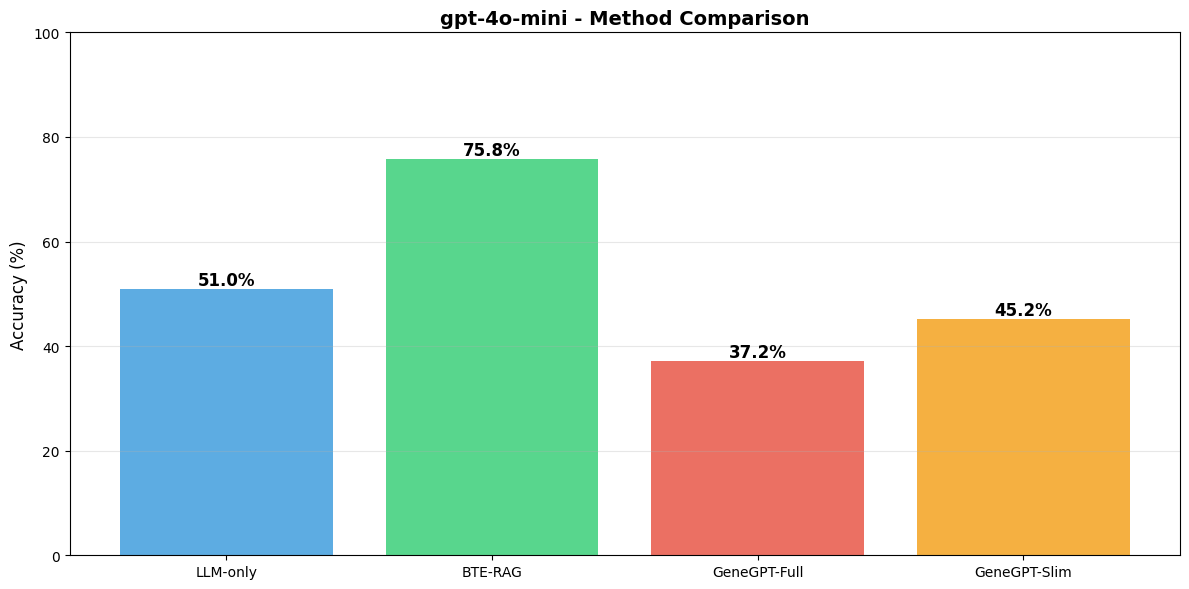

In [35]:
# ============================================================================
# GPT-4o-mini Comparison
# ============================================================================

# LLM-only
df_llm_4omini = gpt4omini_mechanistic_qa_prompt_upd

# BTE-RAG
df_rag_4omini = gpt4omini_bte_thres_1

# GeneGPT (full)
df_genegpt_4omini_full = dfs["data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json"]

# GeneGPT (slim)
df_genegpt_4omini_slim = dfs["data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json"]

# Compare
comparison_4omini = compare_all_methods(
    df_llm=df_llm_4omini,
    df_rag=df_rag_4omini,
    df_genegpt_full=df_genegpt_4omini_full,
    df_genegpt_slim=df_genegpt_4omini_slim,
    model_name="gpt-4o-mini",
    save_dir=None
)


Model: gpt-4o
         Method   Accuracy  Count
0      LLM-only  69.799499    798
1       BTE-RAG  78.571429    798
2  GeneGPT-Full  42.731830    798
3  GeneGPT-Slim  43.984962    798



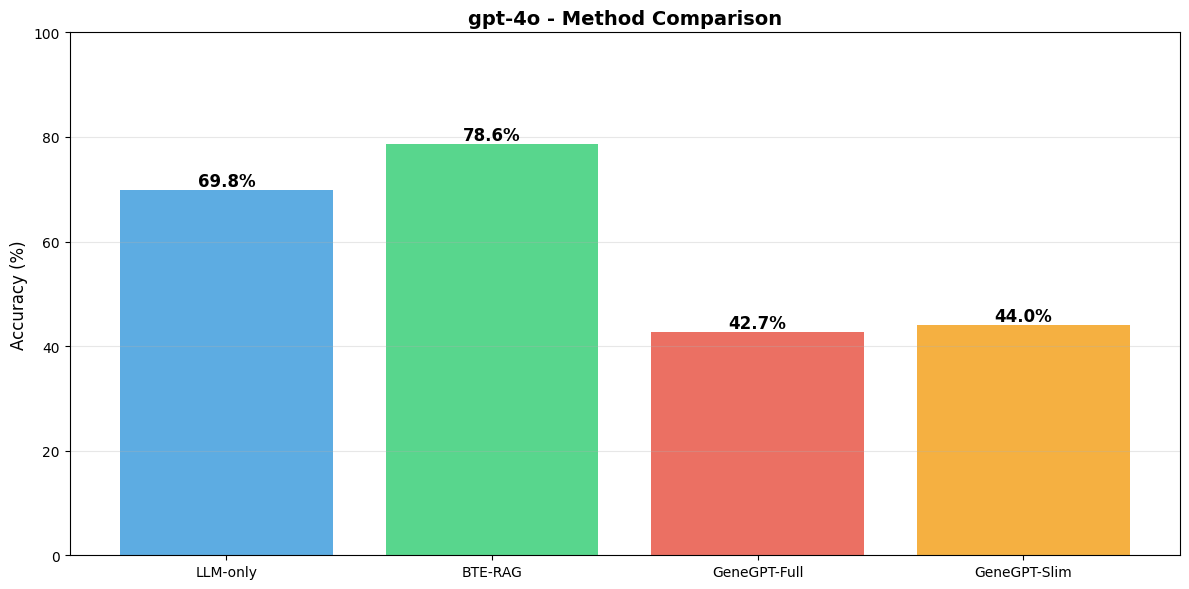

In [36]:
# ============================================================================
# GPT-4o Comparison
# ============================================================================

# LLM-only
df_llm_4o = gpt4o_mechanistic_qa_prompt_upd

# BTE-RAG
df_rag_4o = gpt4o_bte_thres_1

# GeneGPT (full)
df_genegpt_4o_full = dfs["data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json"]

# GeneGPT (slim)
df_genegpt_4o_slim = dfs["data/GeneGPT_results/001001/mech_gene_gpt4o_genegpt_slim.json"]

# Compare
comparison_4o = compare_all_methods(
    df_llm=df_llm_4o,
    df_rag=df_rag_4o,
    df_genegpt_full=df_genegpt_4o_full,
    df_genegpt_slim=df_genegpt_4o_slim,
    model_name="gpt-4o",
    save_dir=None
)

### combined plot

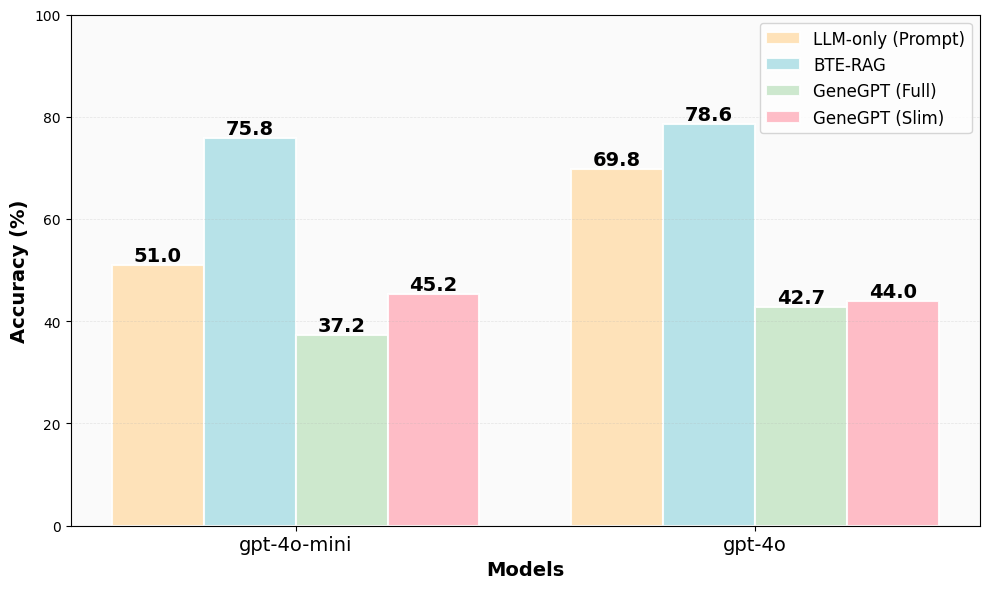

In [37]:
# Data setup
models = ['gpt-4o-mini', 'gpt-4o']
methods = ['LLM-only (Prompt)', 'BTE-RAG', 'GeneGPT (Full)', 'GeneGPT (Slim)']

# Extract accuracy values for each model
gpt_4o_mini_accuracies = comparison_4omini['Accuracy'].values
gpt_4o_accuracies = comparison_4o['Accuracy'].values

# Pastel color palette
colors = ['#FFE0B2', '#B0E0E6', '#C8E6C9','#FFB6C1' ]  
# pastel pink, blue, green, orange

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
x = np.arange(len(models))

for i, method in enumerate(methods):
    accuracies = [gpt_4o_mini_accuracies[i], gpt_4o_accuracies[i]]
    bars = ax.bar(x + i * bar_width, accuracies, bar_width, 
                   label=method, color=colors[i], alpha=0.9, edgecolor='white', linewidth=1.5)
    
    # accuracy values on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Plot
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
# ax.set_title('GeneTuring Gene-Disease Association - Method Comparison', 
#              fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(models, fontsize=14)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', frameon=True, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('figures/geneTuring_gene_disease/combined_geneTuring_comparison_mech_gene_benchmark.png',
            dpi=400, bbox_inches='tight')
plt.show()

# Stats

In [38]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

def calculate_wilson_ci(n_correct, n_total, confidence=0.95):
    """
    Calculate Wilson confidence interval for accuracy
    
    Parameters:
    -----------
    n_correct : int
        Number of correct predictions
    n_total : int
        Total number of predictions
    confidence : float
        Confidence level (default 0.95 for 95% CI)
    
    Returns:
    --------
    tuple : (lower_bound, upper_bound) as percentages
    """
    ci_low, ci_high = proportion_confint(
        n_correct, n_total, 
        alpha=1-confidence, 
        method='wilson'
    )
    return ci_low * 100, ci_high * 100
    
def add_ci_to_mechanistic_llm(df, correct_col="is_correct_in_llm"):
    """
    Add Wilson CI to mechanistic LLM-only results
    """
    n_correct = df[correct_col].sum()
    n_total = len(df)
    accuracy = (n_correct / n_total) * 100
    
    ci_low, ci_high = calculate_wilson_ci(n_correct, n_total)
    
    return {
        'n_correct': n_correct,
        'n_total': n_total,
        'accuracy': accuracy,
        'ci_lower': ci_low,
        'ci_upper': ci_high
    }


def add_ci_to_mechanistic_rag(df, correct_col="result_in_output_sim_10"):
    """
    Add Wilson CI to mechanistic BTE-RAG results
    """
    n_correct = df[correct_col].sum()
    n_total = len(df)
    accuracy = (n_correct / n_total) * 100
    
    ci_low, ci_high = calculate_wilson_ci(n_correct, n_total)
    
    return {
        'n_correct': n_correct,
        'n_total': n_total,
        'accuracy': accuracy,
        'ci_lower': ci_low,
        'ci_upper': ci_high
    }


def add_ci_to_mechanistic_genegpt(df, correct_col="is_correct"):
    """
    Add Wilson CI to mechanistic GeneGPT results
    """
    n_correct = df[correct_col].sum()
    n_total = len(df)
    accuracy = (n_correct / n_total) * 100
    
    ci_low, ci_high = calculate_wilson_ci(n_correct, n_total)
    
    return {
        'n_correct': n_correct,
        'n_total': n_total,
        'accuracy': accuracy,
        'ci_lower': ci_low,
        'ci_upper': ci_high
    }


def prepare_mechanistic_df_for_mcnemar(df, correct_col):
    """
    Add 'correct' column to dataframe for McNemar test
    Handles different column names for correctness
    """
    df = df.copy()
    df['correct'] = df[correct_col].astype(bool)
    return df

In [39]:
# ============================================================================
# CALCULATE CI FOR ALL METHODS - GPT-4o-mini
# ============================================================================

print("="*80)
print("GPT-4o-mini Methods with 95% Wilson CI - Mechanistic Gene Benchmark")
print("="*80)

# LLM-only (GPT-4o-mini)
gpt4omini_mechanistic_qa_prompt_upd = pd.read_csv(
    "data/analysis_results/mechanistic_genes/gpt_4o_mini_prompt-testing_drugmechDB_mechanistic_798qa_count_1.csv"
)
gpt4omini_mechanistic_qa_prompt_upd = process_llm_mechanistic_answers(
    gpt4omini_mechanistic_qa_prompt_upd, 
    extract_answer_function=extract_answer
)
llm_mini_mech_stats = add_ci_to_mechanistic_llm(gpt4omini_mechanistic_qa_prompt_upd)

print(f"\nLLM-only (GPT-4o-mini):")
print(f"  Accuracy: {llm_mini_mech_stats['accuracy']:.2f}% ({llm_mini_mech_stats['n_correct']}/{llm_mini_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{llm_mini_mech_stats['ci_lower']:.2f}%, {llm_mini_mech_stats['ci_upper']:.2f}%]")

# BTE-RAG (GPT-4o-mini)
gpt4omini_bte_thres = pd.read_csv(
    "data/analysis_results/mechanistic_genes/gpt-4o-mini_BTE-RAG_DMDB_mech_genes_full_thresholds_varying.csv"
)
gpt4omini_bte_thres = extract_first_from_list_column(
    gpt4omini_bte_thres,
    source_col="protein",
    target_col="protein_gene_symbol_str"
)
gpt4omini_bte_thres["protein_gene_symbol_str"] = gpt4omini_bte_thres["protein"].apply(ast.literal_eval)
gpt4omini_bte_thres["protein_gene_symbol_str"] = gpt4omini_bte_thres["protein_gene_symbol_str"].str[0]
gpt4omini_bte_thres_1 = process_drugmechDB_v2(gpt4omini_bte_thres, extract_answer)

rag_mini_mech_stats = add_ci_to_mechanistic_rag(gpt4omini_bte_thres_1)

print(f"\nBTE-RAG (GPT-4o-mini):")
print(f"  Accuracy: {rag_mini_mech_stats['accuracy']:.2f}% ({rag_mini_mech_stats['n_correct']}/{rag_mini_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{rag_mini_mech_stats['ci_lower']:.2f}%, {rag_mini_mech_stats['ci_upper']:.2f}%]")

# ============================================================================
# GeneGPT - Use your existing evaluate_results() function
# ============================================================================

# Load GeneGPT data using evaluate_results
files = {
    'full_mini': "data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json",
    'slim_mini': "data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json",
    'full_4o': "data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json",
    'slim_4o': "data/GeneGPT_results/001001/mech_gene_gpt4o_genegpt_slim.json"
}

dfs_genegpt = {}
for name, file in files.items():
    df, acc = evaluate_results(file)  # This already prints results
    dfs_genegpt[name] = df

# Now calculate Wilson CI for each
genegpt_full_mini_mech_df = dfs_genegpt['full_mini']
genegpt_full_mini_mech_stats = add_ci_to_mechanistic_genegpt(genegpt_full_mini_mech_df)

print(f"\nGeneGPT-Full (GPT-4o-mini) - Wilson CI:")
print(f"  Accuracy: {genegpt_full_mini_mech_stats['accuracy']:.2f}% ({genegpt_full_mini_mech_stats['n_correct']}/{genegpt_full_mini_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_full_mini_mech_stats['ci_lower']:.2f}%, {genegpt_full_mini_mech_stats['ci_upper']:.2f}%]")

genegpt_slim_mini_mech_df = dfs_genegpt['slim_mini']
genegpt_slim_mini_mech_stats = add_ci_to_mechanistic_genegpt(genegpt_slim_mini_mech_df)

print(f"\nGeneGPT-Slim (GPT-4o-mini) - Wilson CI:")
print(f"  Accuracy: {genegpt_slim_mini_mech_stats['accuracy']:.2f}% ({genegpt_slim_mini_mech_stats['n_correct']}/{genegpt_slim_mini_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_slim_mini_mech_stats['ci_lower']:.2f}%, {genegpt_slim_mini_mech_stats['ci_upper']:.2f}%]")

print("\n" + "="*80 + "\n")

# ============================================================================
# CALCULATE CI FOR ALL METHODS - GPT-4o
# ============================================================================

print("="*80)
print("GPT-4o Methods with 95% Wilson CI - Mechanistic Gene Benchmark")
print("="*80)

# LLM-only (GPT-4o)
gpt4o_mechanistic_qa_prompt_upd = pd.read_csv(
    "data/analysis_results/mechanistic_genes/gpt_4o_prompt-testing_drugmechDB_mechanistic_798qa_count_1.csv"
)
gpt4o_mechanistic_qa_prompt_upd = process_llm_mechanistic_answers(
    gpt4o_mechanistic_qa_prompt_upd, 
    extract_answer_function=extract_answer
)
llm_4o_mech_stats = add_ci_to_mechanistic_llm(gpt4o_mechanistic_qa_prompt_upd)

print(f"\nLLM-only (GPT-4o):")
print(f"  Accuracy: {llm_4o_mech_stats['accuracy']:.2f}% ({llm_4o_mech_stats['n_correct']}/{llm_4o_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{llm_4o_mech_stats['ci_lower']:.2f}%, {llm_4o_mech_stats['ci_upper']:.2f}%]")

# BTE-RAG (GPT-4o)
gpt4o_bte_thres = pd.read_csv(
    "data/analysis_results/mechanistic_genes/gpt-4o_BTE-RAG_DMDB_mech_genes_full_thresholds_varying.csv"
)
gpt4o_bte_thres = extract_first_from_list_column(
    gpt4o_bte_thres,
    source_col="protein",
    target_col="protein_gene_symbol_str"
)
gpt4o_bte_thres["protein_gene_symbol_str"] = gpt4o_bte_thres["protein"].apply(ast.literal_eval)
gpt4o_bte_thres["protein_gene_symbol_str"] = gpt4o_bte_thres["protein_gene_symbol_str"].str[0]
gpt4o_bte_thres_1 = process_drugmechDB_v2(gpt4o_bte_thres, extract_answer)

rag_4o_mech_stats = add_ci_to_mechanistic_rag(gpt4o_bte_thres_1)

print(f"\nBTE-RAG (GPT-4o):")
print(f"  Accuracy: {rag_4o_mech_stats['accuracy']:.2f}% ({rag_4o_mech_stats['n_correct']}/{rag_4o_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{rag_4o_mech_stats['ci_lower']:.2f}%, {rag_4o_mech_stats['ci_upper']:.2f}%]")

# GeneGPT (already loaded above)
genegpt_full_4o_mech_df = dfs_genegpt['full_4o']
genegpt_full_4o_mech_stats = add_ci_to_mechanistic_genegpt(genegpt_full_4o_mech_df)

print(f"\nGeneGPT-Full (GPT-4o) - Wilson CI:")
print(f"  Accuracy: {genegpt_full_4o_mech_stats['accuracy']:.2f}% ({genegpt_full_4o_mech_stats['n_correct']}/{genegpt_full_4o_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_full_4o_mech_stats['ci_lower']:.2f}%, {genegpt_full_4o_mech_stats['ci_upper']:.2f}%]")

genegpt_slim_4o_mech_df = dfs_genegpt['slim_4o']
genegpt_slim_4o_mech_stats = add_ci_to_mechanistic_genegpt(genegpt_slim_4o_mech_df)

print(f"\nGeneGPT-Slim (GPT-4o) - Wilson CI:")
print(f"  Accuracy: {genegpt_slim_4o_mech_stats['accuracy']:.2f}% ({genegpt_slim_4o_mech_stats['n_correct']}/{genegpt_slim_4o_mech_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_slim_4o_mech_stats['ci_lower']:.2f}%, {genegpt_slim_4o_mech_stats['ci_upper']:.2f}%]")

print("\n" + "="*80 + "\n")

GPT-4o-mini Methods with 95% Wilson CI - Mechanistic Gene Benchmark

LLM-only (GPT-4o-mini):
  Accuracy: 51.00% (407/798)
  Wilson 95% CI: [47.54%, 54.46%]

BTE-RAG (GPT-4o-mini):
  Accuracy: 75.81% (605/798)
  Wilson 95% CI: [72.72%, 78.66%]
Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4omini_genegpt_full.json

Accuracy: 37.22% (297/798)

Value Counts:
is_correct
False    501
True     297
Name: count, dtype: int64

Percentages:
is_correct
False    62.78
True     37.22
Name: proportion, dtype: float64

501 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/001001/mech_gene_gpt4omini_genegpt_slim.json

Accuracy: 45.24% (361/798)

Value Counts:
is_correct
False    437
True     361
Name: count, dtype: int64

Percentages:
is_correct
False    54.76
True     45.24
Name: proportion, dtype: float64

437 Incorrect answers:


Total questions: 798

FILE: data/GeneGPT_results/111111/mech_gene_gpt4o_genegpt_full.json

Accuracy: 42.73% (341/798)

Value Coun

In [40]:
def newcombe_ci(n1_correct, n1_total, n2_correct, n2_total, confidence=0.95):
    """
    Calculate Newcombe hybrid score confidence interval for difference between two proportions
    
    Parameters:
    -----------
    n1_correct : int
        Number of correct predictions for method 1
    n1_total : int
        Total predictions for method 1
    n2_correct : int
        Number of correct predictions for method 2
    n2_total : int
        Total predictions for method 2
    confidence : float
        Confidence level (default 0.95)
    
    Returns:
    --------
    dict with:
        - diff: difference in proportions (p1 - p2) as percentage
        - ci_lower: lower bound of CI for difference
        - ci_upper: upper bound of CI for difference
        - p1, p2: individual proportions
    """
    from statsmodels.stats.proportion import proportion_confint
    
    # Calculate proportions
    p1 = n1_correct / n1_total
    p2 = n2_correct / n2_total
    diff = (p1 - p2) * 100
    
    # Get Wilson CIs for each proportion
    l1, u1 = proportion_confint(n1_correct, n1_total, alpha=1-confidence, method='wilson')
    l2, u2 = proportion_confint(n2_correct, n2_total, alpha=1-confidence, method='wilson')
    
    # Newcombe hybrid score interval for difference
    # Lower bound: (p1 - p2) - sqrt((p1 - l1)^2 + (u2 - p2)^2)
    # Upper bound: (p1 - p2) + sqrt((u1 - p1)^2 + (p2 - l2)^2)
    
    ci_lower = (p1 - p2) - np.sqrt((p1 - l1)**2 + (u2 - p2)**2)
    ci_upper = (p1 - p2) + np.sqrt((u1 - p1)**2 + (p2 - l2)**2)
    
    return {
        'p1': p1 * 100,
        'p2': p2 * 100,
        'diff': diff,
        'ci_lower': ci_lower * 100,
        'ci_upper': ci_upper * 100
    }


def mcnemar_test_paired(df1, df2, method1_name, method2_name):
    """
    Perform McNemar's test for paired data (same test questions)
    
    Parameters:
    -----------
    df1, df2 : DataFrames
        Must have 'correct' or 'is_correct' column and same length
    method1_name, method2_name : str
        Names for display
    
    Returns:
    --------
    dict with test results
    """
    # Ensure same length
    assert len(df1) == len(df2), f"DataFrames must have same length. Got {len(df1)} and {len(df2)}"
    
    # Get correctness columns (handle both column names)
    if 'correct' in df1.columns:
        correct1 = df1['correct'].values
    elif 'is_correct' in df1.columns:
        correct1 = df1['is_correct'].values
    else:
        raise ValueError("df1 must have 'correct' or 'is_correct' column")
    
    if 'correct' in df2.columns:
        correct2 = df2['correct'].values
    elif 'is_correct' in df2.columns:
        correct2 = df2['is_correct'].values
    else:
        raise ValueError("df2 must have 'correct' or 'is_correct' column")
    
    # Create contingency table
    both_correct = (correct1 & correct2).sum()
    method1_only = (correct1 & ~correct2).sum()
    method2_only = (~correct1 & correct2).sum()
    both_wrong = (~correct1 & ~correct2).sum()
    
    # Contingency table for McNemar's test
    # Format: [[both_correct, method1_correct_method2_wrong],
    #          [method1_wrong_method2_correct, both_wrong]]
    contingency_table = np.array([[both_correct, method1_only],
                                   [method2_only, both_wrong]])
    
    print(f"\n{'='*80}")
    print(f"McNemar's Test: {method1_name} vs {method2_name}")
    print(f"{'='*80}")
    print(f"\nContingency Table:")
    print(f"{'':30} {method2_name} Correct    {method2_name} Wrong")
    print(f"{method1_name} Correct:     {both_correct:6d}            {method1_only:6d}")
    print(f"{method1_name} Wrong:       {method2_only:6d}            {both_wrong:6d}")
    
    # McNemar's test
    # Use exact test if sum of discordant pairs < 25, otherwise continuity correction
    use_exact = (method1_only + method2_only) < 25
    
    result = mcnemar(contingency_table, exact=use_exact, correction=not use_exact)
    
    print(f"\nDiscordant pairs: {method1_only + method2_only}")
    print(f"  {method1_name} correct, {method2_name} wrong: {method1_only}")
    print(f"  {method1_name} wrong, {method2_name} correct: {method2_only}")
    print(f"\nMcNemar's statistic: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.6f}")
    
    if result.pvalue < 0.001:
        sig_str = "p < 0.001 ***"
        interpretation = "HIGHLY SIGNIFICANT"
    elif result.pvalue < 0.01:
        sig_str = "p < 0.01 **"
        interpretation = "VERY SIGNIFICANT"
    elif result.pvalue < 0.05:
        sig_str = "p < 0.05 *"
        interpretation = "SIGNIFICANT"
    else:
        sig_str = "not significant (p ≥ 0.05)"
        interpretation = "NOT SIGNIFICANT"
    
    print(f"Result: {sig_str}")
    print(f"Interpretation: {interpretation}")
    
    # Determine which method is better
    if method1_only > method2_only:
        better = method1_name
    elif method2_only > method1_only:
        better = method2_name
    else:
        better = "TIE"
    
    print(f"Better method: {better}")
    print(f"{'='*80}\n")
    
    return {
        'method1': method1_name,
        'method2': method2_name,
        'both_correct': both_correct,
        'method1_only': method1_only,
        'method2_only': method2_only,
        'both_wrong': both_wrong,
        'statistic': result.statistic,
        'pvalue': result.pvalue,
        'significant': result.pvalue < 0.05,
        'better_method': better
    }


In [41]:
print("\n" + "="*80)
print("PREPARING DATAFRAMES FOR MCNEMAR TEST")
print("="*80 + "\n")

# Prepare LLM-only and BTE-RAG dataframes with 'correct' column
gpt4omini_llm_mech_eval = prepare_mechanistic_df_for_mcnemar(
    gpt4omini_mechanistic_qa_prompt_upd, 'is_correct_in_llm'
)
gpt4omini_rag_mech_eval = prepare_mechanistic_df_for_mcnemar(
    gpt4omini_bte_thres_1, 'result_in_output_sim_10'
)
gpt4o_llm_mech_eval = prepare_mechanistic_df_for_mcnemar(
    gpt4o_mechanistic_qa_prompt_upd, 'is_correct_in_llm'
)
gpt4o_rag_mech_eval = prepare_mechanistic_df_for_mcnemar(
    gpt4o_bte_thres_1, 'result_in_output_sim_10'
)

# GeneGPT dataframes already have 'is_correct' column, add 'correct' for consistency
df_full_4omini_mech = genegpt_full_mini_mech_df.copy()
df_full_4omini_mech['correct'] = df_full_4omini_mech['is_correct'].astype(bool)

df_slim_4omini_mech = genegpt_slim_mini_mech_df.copy()
df_slim_4omini_mech['correct'] = df_slim_4omini_mech['is_correct'].astype(bool)

df_full_4o_mech = genegpt_full_4o_mech_df.copy()
df_full_4o_mech['correct'] = df_full_4o_mech['is_correct'].astype(bool)

df_slim_4o_mech = genegpt_slim_4o_mech_df.copy()
df_slim_4o_mech['correct'] = df_slim_4o_mech['is_correct'].astype(bool)

print("✓ All dataframes prepared with 'correct' column\n")

# ============================================================================
# PAIRWISE COMPARISONS - GPT-4o-mini
# ============================================================================

print("\n" + "#"*80)
print("PAIRWISE COMPARISONS FOR GPT-4o-mini - Mechanistic Gene Benchmark")
print("#"*80 + "\n")

# Comparison 1: BTE-RAG vs LLM-only (GPT-4o-mini)
print("="*80)
print("1. BTE-RAG vs LLM-only (GPT-4o-mini)")
print("="*80)

newcombe_mech_1 = newcombe_ci(
    rag_mini_mech_stats['n_correct'], rag_mini_mech_stats['n_total'],
    llm_mini_mech_stats['n_correct'], llm_mini_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_1['p1']:.2f}%")
print(f"  LLM-only accuracy: {newcombe_mech_1['p2']:.2f}%")
print(f"  Difference (BTE-RAG - LLM-only): {newcombe_mech_1['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_1['ci_lower']:.2f}%, {newcombe_mech_1['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_1['diff']:.2f} percentage points")

mcnemar_mech_1 = mcnemar_test_paired(
    gpt4omini_rag_mech_eval,
    gpt4omini_llm_mech_eval,
    'BTE-RAG', 'LLM-only'
)

# Comparison 2: BTE-RAG vs GeneGPT-Full (GPT-4o-mini)
print("\n" + "="*80)
print("2. BTE-RAG vs GeneGPT-Full (GPT-4o-mini)")
print("="*80)

newcombe_mech_2 = newcombe_ci(
    rag_mini_mech_stats['n_correct'], rag_mini_mech_stats['n_total'],
    genegpt_full_mini_mech_stats['n_correct'], genegpt_full_mini_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_2['p1']:.2f}%")
print(f"  GeneGPT-Full accuracy: {newcombe_mech_2['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Full): {newcombe_mech_2['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_2['ci_lower']:.2f}%, {newcombe_mech_2['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_2['diff']:.2f} percentage points")

mcnemar_mech_2 = mcnemar_test_paired(
    gpt4omini_rag_mech_eval,
    df_full_4omini_mech,
    'BTE-RAG', 'GeneGPT-Full'
)

# Comparison 3: BTE-RAG vs GeneGPT-Slim (GPT-4o-mini)
print("\n" + "="*80)
print("3. BTE-RAG vs GeneGPT-Slim (GPT-4o-mini)")
print("="*80)

newcombe_mech_3 = newcombe_ci(
    rag_mini_mech_stats['n_correct'], rag_mini_mech_stats['n_total'],
    genegpt_slim_mini_mech_stats['n_correct'], genegpt_slim_mini_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_3['p1']:.2f}%")
print(f"  GeneGPT-Slim accuracy: {newcombe_mech_3['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Slim): {newcombe_mech_3['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_3['ci_lower']:.2f}%, {newcombe_mech_3['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_3['diff']:.2f} percentage points")

mcnemar_mech_3 = mcnemar_test_paired(
    gpt4omini_rag_mech_eval,
    df_slim_4omini_mech,
    'BTE-RAG', 'GeneGPT-Slim'
)

# ============================================================================
# PAIRWISE COMPARISONS - GPT-4o
# ============================================================================

print("\n" + "#"*80)
print("PAIRWISE COMPARISONS FOR GPT-4o - Mechanistic Gene Benchmark")
print("#"*80 + "\n")

# Comparison 4: BTE-RAG vs LLM-only (GPT-4o)
print("="*80)
print("4. BTE-RAG vs LLM-only (GPT-4o)")
print("="*80)

newcombe_mech_4 = newcombe_ci(
    rag_4o_mech_stats['n_correct'], rag_4o_mech_stats['n_total'],
    llm_4o_mech_stats['n_correct'], llm_4o_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_4['p1']:.2f}%")
print(f"  LLM-only accuracy: {newcombe_mech_4['p2']:.2f}%")
print(f"  Difference (BTE-RAG - LLM-only): {newcombe_mech_4['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_4['ci_lower']:.2f}%, {newcombe_mech_4['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_4['diff']:.2f} percentage points")

mcnemar_mech_4 = mcnemar_test_paired(
    gpt4o_rag_mech_eval,
    gpt4o_llm_mech_eval,
    'BTE-RAG', 'LLM-only'
)

# Comparison 5: BTE-RAG vs GeneGPT-Full (GPT-4o)
print("\n" + "="*80)
print("5. BTE-RAG vs GeneGPT-Full (GPT-4o)")
print("="*80)

newcombe_mech_5 = newcombe_ci(
    rag_4o_mech_stats['n_correct'], rag_4o_mech_stats['n_total'],
    genegpt_full_4o_mech_stats['n_correct'], genegpt_full_4o_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_5['p1']:.2f}%")
print(f"  GeneGPT-Full accuracy: {newcombe_mech_5['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Full): {newcombe_mech_5['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_5['ci_lower']:.2f}%, {newcombe_mech_5['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_5['diff']:.2f} percentage points")

mcnemar_mech_5 = mcnemar_test_paired(
    gpt4o_rag_mech_eval,
    df_full_4o_mech,
    'BTE-RAG', 'GeneGPT-Full'
)

# Comparison 6: BTE-RAG vs GeneGPT-Slim (GPT-4o)
print("\n" + "="*80)
print("6. BTE-RAG vs GeneGPT-Slim (GPT-4o)")
print("="*80)

newcombe_mech_6 = newcombe_ci(
    rag_4o_mech_stats['n_correct'], rag_4o_mech_stats['n_total'],
    genegpt_slim_4o_mech_stats['n_correct'], genegpt_slim_4o_mech_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_mech_6['p1']:.2f}%")
print(f"  GeneGPT-Slim accuracy: {newcombe_mech_6['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Slim): {newcombe_mech_6['diff']:.2f}%")
print(f"  95% CI: [{newcombe_mech_6['ci_lower']:.2f}%, {newcombe_mech_6['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_mech_6['diff']:.2f} percentage points")

mcnemar_mech_6 = mcnemar_test_paired(
    gpt4o_rag_mech_eval,
    df_slim_4o_mech,
    'BTE-RAG', 'GeneGPT-Slim'
)

# ============================================================================
# SUMMARY TABLE OF ALL COMPARISONS
# ============================================================================

comparison_mech_summary = pd.DataFrame([
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs LLM-only',
        'Method1_Acc': newcombe_mech_1['p1'],
        'Method2_Acc': newcombe_mech_1['p2'],
        'Difference': newcombe_mech_1['diff'],
        'Newcombe_CI': f"[{newcombe_mech_1['ci_lower']:.2f}, {newcombe_mech_1['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_1['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_1['significant'] else 'No',
        'Better': mcnemar_mech_1['better_method']
    },
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs GeneGPT-Full',
        'Method1_Acc': newcombe_mech_2['p1'],
        'Method2_Acc': newcombe_mech_2['p2'],
        'Difference': newcombe_mech_2['diff'],
        'Newcombe_CI': f"[{newcombe_mech_2['ci_lower']:.2f}, {newcombe_mech_2['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_2['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_2['significant'] else 'No',
        'Better': mcnemar_mech_2['better_method']
    },
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs GeneGPT-Slim',
        'Method1_Acc': newcombe_mech_3['p1'],
        'Method2_Acc': newcombe_mech_3['p2'],
        'Difference': newcombe_mech_3['diff'],
        'Newcombe_CI': f"[{newcombe_mech_3['ci_lower']:.2f}, {newcombe_mech_3['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_3['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_3['significant'] else 'No',
        'Better': mcnemar_mech_3['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs LLM-only',
        'Method1_Acc': newcombe_mech_4['p1'],
        'Method2_Acc': newcombe_mech_4['p2'],
        'Difference': newcombe_mech_4['diff'],
        'Newcombe_CI': f"[{newcombe_mech_4['ci_lower']:.2f}, {newcombe_mech_4['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_4['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_4['significant'] else 'No',
        'Better': mcnemar_mech_4['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs GeneGPT-Full',
        'Method1_Acc': newcombe_mech_5['p1'],
        'Method2_Acc': newcombe_mech_5['p2'],
        'Difference': newcombe_mech_5['diff'],
        'Newcombe_CI': f"[{newcombe_mech_5['ci_lower']:.2f}, {newcombe_mech_5['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_5['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_5['significant'] else 'No',
        'Better': mcnemar_mech_5['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs GeneGPT-Slim',
        'Method1_Acc': newcombe_mech_6['p1'],
        'Method2_Acc': newcombe_mech_6['p2'],
        'Difference': newcombe_mech_6['diff'],
        'Newcombe_CI': f"[{newcombe_mech_6['ci_lower']:.2f}, {newcombe_mech_6['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_mech_6['pvalue'],
        'Significant': 'Yes' if mcnemar_mech_6['significant'] else 'No',
        'Better': mcnemar_mech_6['better_method']
    }
])

print("\n" + "="*120)
print("COMPREHENSIVE PAIRWISE COMPARISON SUMMARY - Mechanistic Gene Benchmark")
print("="*120)
print(comparison_mech_summary.to_string(index=False))
print("="*120 + "\n")


PREPARING DATAFRAMES FOR MCNEMAR TEST

✓ All dataframes prepared with 'correct' column


################################################################################
PAIRWISE COMPARISONS FOR GPT-4o-mini - Mechanistic Gene Benchmark
################################################################################

1. BTE-RAG vs LLM-only (GPT-4o-mini)

Newcombe 95% CI for Difference:
  BTE-RAG accuracy: 75.81%
  LLM-only accuracy: 51.00%
  Difference (BTE-RAG - LLM-only): 24.81%
  95% CI: [20.18%, 29.29%]
  Interpretation: BTE-RAG is better by 24.81 percentage points

McNemar's Test: BTE-RAG vs LLM-only

Contingency Table:
                               LLM-only Correct    LLM-only Wrong
BTE-RAG Correct:        360               245
BTE-RAG Wrong:           47               146

Discordant pairs: 292
  BTE-RAG correct, LLM-only wrong: 245
  BTE-RAG wrong, LLM-only correct: 47

McNemar's statistic: 132.9075
P-value: 0.000000
Result: p < 0.001 ***
Interpretation: HIGHLY SIGNIFICANT
Bet

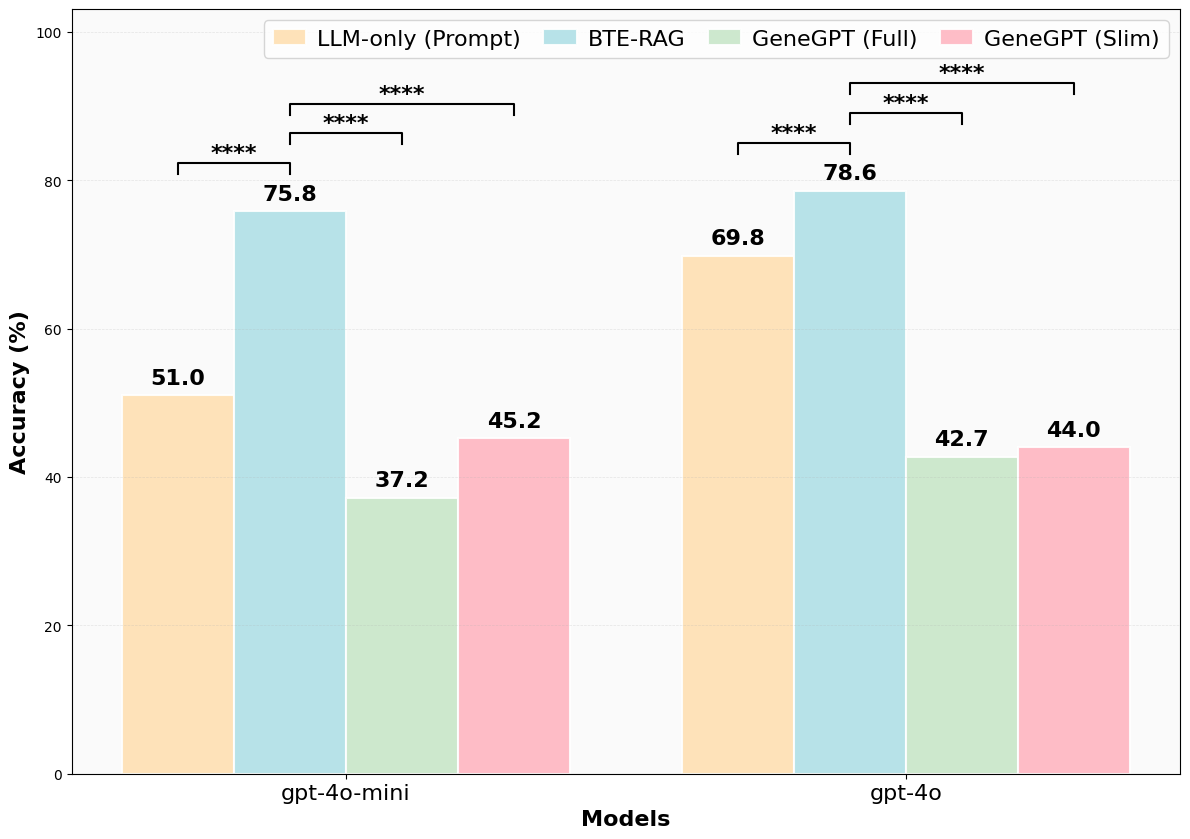

Saved: figures/mechanistic_genes/combined_mechanistic_gene_comparison.png


In [53]:
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=16, lw=1.5):
    """Draw significance bracket between x1 and x2 at height y, with bracket height h."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y],
            lw=lw, c="black", clip_on=False)
    ax.text((x1 + x2) / 2, y + h, text,
            ha="center", va="bottom", fontsize=fontsize, clip_on=False, fontweight='bold')

# -----------------------------
# data from your comparison dfs
# -----------------------------
models  = ["gpt-4o-mini", "gpt-4o"]
methods = ["LLM-only (Prompt)", "BTE-RAG", "GeneGPT (Full)", "GeneGPT (Slim)"]

# Must be in the same order as 'methods' above
gpt_4o_mini_accuracies = comparison_4omini["Accuracy"].values
gpt_4o_accuracies      = comparison_4o["Accuracy"].values

# Pastel colors (match your style)
colors = ["#FFE0B2", "#B0E0E6", "#C8E6C9", "#FFB6C1"]  # orange, blue, green, pink

# -----------------------------
# significance p-values (McNemar)
# BTE-RAG vs: LLM-only, Full, Slim
# -----------------------------
pvals_by_model = {
    0: {0: mcnemar_mech_1["pvalue"], 2: mcnemar_mech_2["pvalue"], 3: mcnemar_mech_3["pvalue"]},  # mini
    1: {0: mcnemar_mech_4["pvalue"], 2: mcnemar_mech_5["pvalue"], 3: mcnemar_mech_6["pvalue"]},  # 4o
}

bte_idx = 1
comparators = [0, 2, 3]  # LLM-only, Full, Slim

# -----------------------------
# plot
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8.5))  # Compact size like reference
bar_width = 0.2
x = np.arange(len(models))

bar_centers = {}  # (model_idx, method_idx) -> x_center
bar_tops    = {}  # (model_idx, method_idx) -> y_height

for method_idx, method in enumerate(methods):
    accuracies = [gpt_4o_mini_accuracies[method_idx], gpt_4o_accuracies[method_idx]]

    bars = ax.bar(
        x + method_idx * bar_width, accuracies, bar_width,
        label=method, color=colors[method_idx], alpha=0.9,
        edgecolor="white", linewidth=1.5
    )

    for model_idx, bar in enumerate(bars):
        height = float(bar.get_height())
        xc = bar.get_x() + bar.get_width() / 2

        bar_centers[(model_idx, method_idx)] = xc
        bar_tops[(model_idx, method_idx)] = height

        # bar value label
        ax.text(
            xc, height + 1.0, f"{height:.1f}",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold",
            clip_on=False
        )

# axes formatting
ax.set_ylabel("Accuracy (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Models", fontsize=16, fontweight="bold")
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(models, fontsize=16)
ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
ax.set_facecolor("#FAFAFA")

# legend INSIDE top right - single row (ncol=4)
ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=16,
    ncol=4,  
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.5
)


pad  = 5.0   # above max(bar pair)
step = 4.0   # min vertical separation between brackets
h    = 1.5   # bracket height

max_bracket_y = 0.0

for model_idx in [0, 1]:
    used_y = []  

    for comp_idx in comparators:
        x1 = bar_centers[(model_idx, bte_idx)]
        x2 = bar_centers[(model_idx, comp_idx)]
        p  = pvals_by_model[model_idx][comp_idx]

        y_base = max(bar_tops[(model_idx, bte_idx)], bar_tops[(model_idx, comp_idx)]) + pad
        y = y_base

        while any(abs(y - yy) < step for yy in used_y):
            y += step
        used_y.append(y)

        label = p_to_stars(p)  # stars-only
        add_sig_bracket(ax, min(x1, x2), max(x1, x2), y, h, label, fontsize=16)
        max_bracket_y = max(max_bracket_y, y + h)

# dynamic y-limits
max_bar = max(bar_tops.values())
top = max(max_bar + 12, max_bracket_y + 10)
ax.set_ylim(0, top)  

plt.tight_layout()

outpath = "figures/mechanistic_genes/combined_mechanistic_gene_comparison_significance.png"
plt.savefig(
    outpath,
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.2
)
plt.show()

print(f"Saved: {outpath}")


Saved: figures/mechanistic_genes/combined_contingency_tables_mech_gene.png


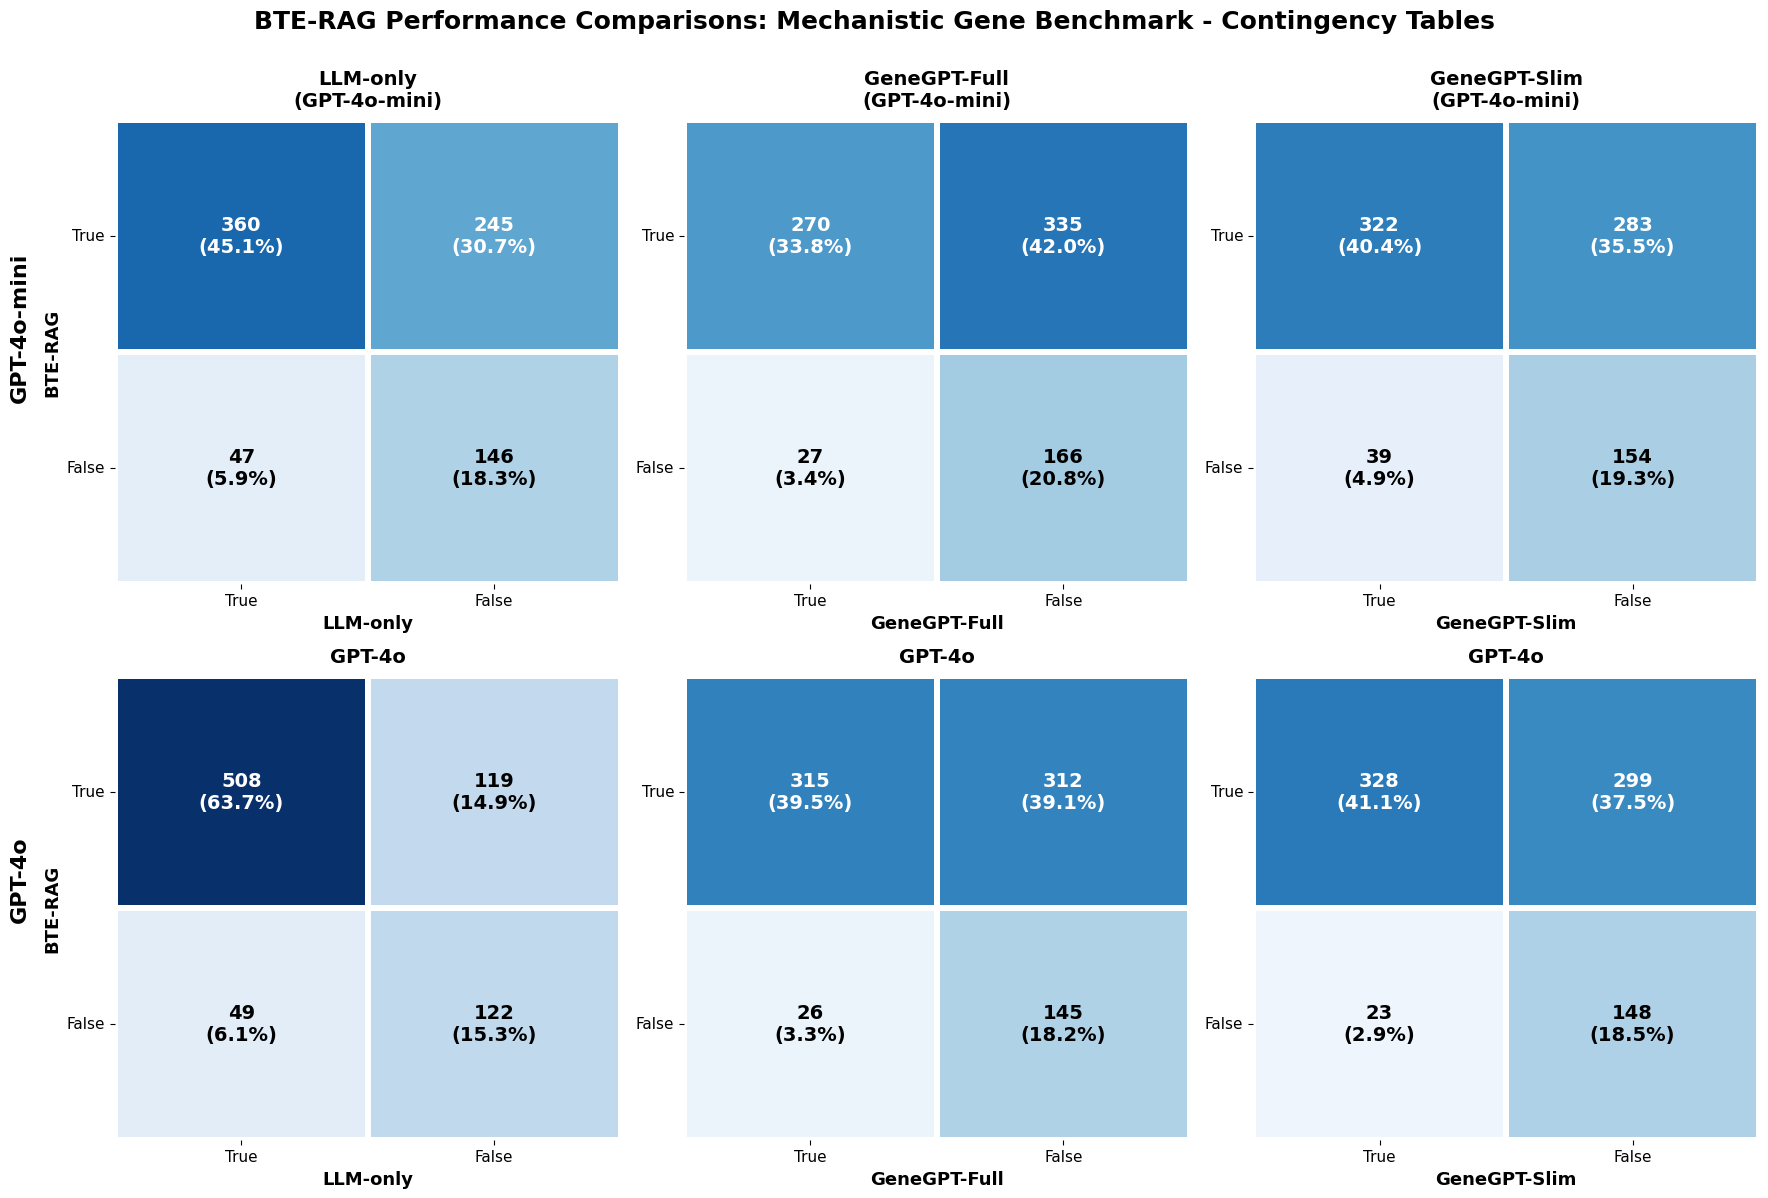


CONTINGENCY TABLE SUMMARY - Mechanistic Gene Benchmark

GPT-4o-mini - BTE-RAG vs LLM-only:
  Both correct: 360 (45.1%)
  BTE-RAG only: 245 (30.7%)
  LLM-only only: 47 (5.9%)
  Both wrong: 146 (18.3%)
  Agreement: 63.4%, Disagreement: 36.6%

GPT-4o-mini - BTE-RAG vs GeneGPT-Full:
  Both correct: 270 (33.8%)
  BTE-RAG only: 335 (42.0%)
  GeneGPT-Full only: 27 (3.4%)
  Both wrong: 166 (20.8%)
  Agreement: 54.6%, Disagreement: 45.4%

GPT-4o-mini - BTE-RAG vs GeneGPT-Slim:
  Both correct: 322 (40.4%)
  BTE-RAG only: 283 (35.5%)
  GeneGPT-Slim only: 39 (4.9%)
  Both wrong: 154 (19.3%)
  Agreement: 59.6%, Disagreement: 40.4%

GPT-4o - BTE-RAG vs LLM-only:
  Both correct: 508 (63.7%)
  BTE-RAG only: 119 (14.9%)
  LLM-only only: 49 (6.1%)
  Both wrong: 122 (15.3%)
  Agreement: 78.9%, Disagreement: 21.1%

GPT-4o - BTE-RAG vs GeneGPT-Full:
  Both correct: 315 (39.5%)
  BTE-RAG only: 312 (39.1%)
  GeneGPT-Full only: 26 (3.3%)
  Both wrong: 145 (18.2%)
  Agreement: 57.6%, Disagreement: 42.4%

GPT-

In [42]:
# ============================================================================
# CREATE CONTINGENCY TABLE VISUALIZATION (3x2 format)
# ============================================================================

def plot_combined_contingency_grid_mechanistic(save_path=None):
    """
    Create a single publication-ready figure with 2x3 contingency table heatmaps
    for mechanistic gene benchmark
    Rows: GPT-4o-mini (top), GPT-4o (bottom)
    Cols: BTE-RAG vs LLM-only, BTE-RAG vs GeneGPT-Full, BTE-RAG vs GeneGPT-Slim
    """
    
    # Helper function to get correctness values
    def get_correct(df):
        if 'correct' in df.columns:
            return df['correct'].values
        elif 'is_correct' in df.columns:
            return df['is_correct'].values
    
    # Helper function to create contingency table
    def get_contingency(correct1, correct2):
        both_correct = (correct1 & correct2).sum()
        method1_only = (correct1 & ~correct2).sum()
        method2_only = (~correct1 & correct2).sum()
        both_wrong = (~correct1 & ~correct2).sum()
        return np.array([[both_correct, method1_only],
                        [method2_only, both_wrong]])
    
    # Get correctness arrays for GPT-4o-mini
    correct_rag_mini = get_correct(gpt4omini_rag_mech_eval)
    correct_llm_mini = get_correct(gpt4omini_llm_mech_eval)
    correct_full_mini = get_correct(df_full_4omini_mech)
    correct_slim_mini = get_correct(df_slim_4omini_mech)
    
    # Get correctness arrays for GPT-4o
    correct_rag_4o = get_correct(gpt4o_rag_mech_eval)
    correct_llm_4o = get_correct(gpt4o_llm_mech_eval)
    correct_full_4o = get_correct(df_full_4o_mech)
    correct_slim_4o = get_correct(df_slim_4o_mech)
    
    # Create contingency tables
    # Row 1: GPT-4o-mini
    cont_mini_llm = get_contingency(correct_rag_mini, correct_llm_mini)
    cont_mini_full = get_contingency(correct_rag_mini, correct_full_mini)
    cont_mini_slim = get_contingency(correct_rag_mini, correct_slim_mini)
    
    # Row 2: GPT-4o
    cont_4o_llm = get_contingency(correct_rag_4o, correct_llm_4o)
    cont_4o_full = get_contingency(correct_rag_4o, correct_full_4o)
    cont_4o_slim = get_contingency(correct_rag_4o, correct_slim_4o)
    
    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Define data for each subplot
    plot_data = [
        # Row 1: GPT-4o-mini
        [(0, 0), cont_mini_llm, 'LLM-only', 'GPT-4o-mini'],
        [(0, 1), cont_mini_full, 'GeneGPT-Full', 'GPT-4o-mini'],
        [(0, 2), cont_mini_slim, 'GeneGPT-Slim', 'GPT-4o-mini'],
        # Row 2: GPT-4o
        [(1, 0), cont_4o_llm, 'LLM-only', 'GPT-4o'],
        [(1, 1), cont_4o_full, 'GeneGPT-Full', 'GPT-4o'],
        [(1, 2), cont_4o_slim, 'GeneGPT-Slim', 'GPT-4o'],
    ]
    
    # Plot each contingency table
    for (row, col), contingency, method2_name, model_name in plot_data:
        ax = axes[row, col]
        
        # Calculate percentages
        total = contingency.sum()
        percentages = (contingency / total * 100)
        
        # Create heatmap
        sns.heatmap(contingency, annot=False, fmt='d', cmap='Blues',
                   cbar=False, linewidths=3, linecolor='white', ax=ax,
                   vmin=0, vmax=max(cont_mini_llm.max(), cont_4o_llm.max()) * 0.9)
        
        # Add custom annotations with counts and percentages
        for i in range(2):
            for j in range(2):
                count = contingency[i, j]
                pct = percentages[i, j]
                text = f'{count}\n({pct:.1f}%)'
                
                # Determine text color based on background
                text_color = 'white' if contingency[i, j] > contingency.max()/2 else 'black'
                
                ax.text(j + 0.5, i + 0.5, text,
                       ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color=text_color)
        
        # Set labels
        ax.set_xlabel(method2_name, fontsize=13, fontweight='bold')
        
        # Only show y-label on leftmost column
        if col == 0:
            ax.set_ylabel('BTE-RAG', fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
        
        # Set tick labels
        ax.set_xticklabels(['True', 'False'], fontsize=11)
        ax.set_yticklabels(['True', 'False'], fontsize=11, rotation=0)
        
        # Add subplot title (only model name on top row)
        if row == 0:
            ax.set_title(f'{method2_name}\n({model_name})', 
                        fontsize=14, fontweight='bold', pad=10)
        else:
            ax.set_title(f'{model_name}', 
                        fontsize=14, fontweight='bold', pad=10)
    
    # Add overall title
    fig.suptitle('BTE-RAG Performance Comparisons: Mechanistic Gene Benchmark - Contingency Tables', 
                fontsize=18, fontweight='bold', y=0.995)
    
    # Add row labels on the left
    fig.text(0.02, 0.73, 'GPT-4o-mini', fontsize=16, fontweight='bold', 
            rotation=90, va='center')
    fig.text(0.02, 0.27, 'GPT-4o', fontsize=16, fontweight='bold', 
            rotation=90, va='center')
    
    plt.tight_layout(rect=[0.03, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("CONTINGENCY TABLE SUMMARY - Mechanistic Gene Benchmark")
    print("="*80)
    
    comparisons = [
        ("GPT-4o-mini", "LLM-only", cont_mini_llm),
        ("GPT-4o-mini", "GeneGPT-Full", cont_mini_full),
        ("GPT-4o-mini", "GeneGPT-Slim", cont_mini_slim),
        ("GPT-4o", "LLM-only", cont_4o_llm),
        ("GPT-4o", "GeneGPT-Full", cont_4o_full),
        ("GPT-4o", "GeneGPT-Slim", cont_4o_slim),
    ]
    
    for model, method2, cont in comparisons:
        both_correct = cont[0, 0]
        bte_only = cont[0, 1]
        method2_only = cont[1, 0]
        both_wrong = cont[1, 1]
        total = cont.sum()
        
        agreement = (both_correct + both_wrong) / total * 100
        disagreement = (bte_only + method2_only) / total * 100
        
        print(f"\n{model} - BTE-RAG vs {method2}:")
        print(f"  Both correct: {both_correct} ({both_correct/total*100:.1f}%)")
        print(f"  BTE-RAG only: {bte_only} ({bte_only/total*100:.1f}%)")
        print(f"  {method2} only: {method2_only} ({method2_only/total*100:.1f}%)")
        print(f"  Both wrong: {both_wrong} ({both_wrong/total*100:.1f}%)")
        print(f"  Agreement: {agreement:.1f}%, Disagreement: {disagreement:.1f}%")
    
    print("\n" + "="*80 + "\n")


# Create the combined contingency table plot
plot_combined_contingency_grid_mechanistic(
    save_path= 'figures/mechanistic_genes/combined_contingency_tables_mech_gene.png'
)



# Gene-Turing Dataset

## LLM-only

In [54]:
def extract_gene_prediction(df, output_col="output_NC", new_col="predicted_gene"):

    def extract_answer(raw):
        if pd.isna(raw):
            return None
        # Clean markdown-style JSON blocks
        cleaned = str(raw).strip()
        cleaned = re.sub(r"^```(?:json)?", "", cleaned, flags=re.IGNORECASE).strip()
        cleaned = re.sub(r"```$", "", cleaned).strip()
        try:
            parsed = json.loads(cleaned)
            return parsed.get("answer", "").strip().upper()
        except Exception:
            return None

    df = df.copy()
    df[new_col] = df[output_col].apply(extract_answer)
    return df

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compare_predictions_to_gold(df, pred_col="predicted_gene", gold_col="Goldstandard"):
    df = df.copy()

    # Normalize both gold and predicted
    df["Goldstandard_norm"] = (
        df[gold_col]
        .astype(str)
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
    )
    df["Pred_norm"] = (
        df[pred_col]
        .astype(str)
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
    )

    # Correct if prediction appears within comma-separated gold list
    df["correct"] = df.apply(
        lambda row: (
            isinstance(row["Pred_norm"], str)
            and row["Pred_norm"] in row["Goldstandard_norm"].split(",")
        ),
        axis=1,
    )

    # Only include rows with predictions
    valid_rows = df[pred_col].notna()
    y_true = df.loc[valid_rows, "Goldstandard_norm"]
    y_pred = df.loc[valid_rows, pred_col]

    # Compute metrics (micro accuracy on correct flag)
    metrics = {
        "N": len(df),
        "Valid Predictions": valid_rows.sum(),
        "Correct": df["correct"].sum(),
        "Accuracy": df["correct"].mean(),  # simpler and robust
        "Precision": precision_score(df["correct"], [True]*len(df), average='binary', zero_division=0)
        if df["correct"].any() else 0.0,
        "Recall": df["correct"].mean(),
        "F1 Score": f1_score(df["correct"], [True]*len(df), zero_division=0)
        if df["correct"].any() else 0.0,
    }

    return df, metrics

In [56]:
gpt4omini_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_mini_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_prompt.shape

(100, 5)

In [57]:
gpt4omini_df = extract_gene_prediction(gpt4omini_prompt, output_col="llm_answer_prompt_test")


In [58]:
evaluated_df, metrics = compare_predictions_to_gold(gpt4omini_df,pred_col="predicted_gene")

print(" Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

 Evaluation Metrics:
N: 100
Valid Predictions: 100
Correct: 33
Accuracy: 0.330
Precision: 0.330
Recall: 0.330
F1 Score: 0.496


In [59]:
gpt4o_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_prompt.shape

(100, 5)

In [60]:
gpt4o_df = extract_gene_prediction(gpt4o_prompt, output_col="llm_answer_prompt_test")


In [61]:
evaluated_df, metrics = compare_predictions_to_gold(gpt4o_df,pred_col="predicted_gene")

print(" Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

 Evaluation Metrics:
N: 100
Valid Predictions: 100
Correct: 56
Accuracy: 0.560
Precision: 0.560
Recall: 0.560
F1 Score: 0.718


## BTE-RAG

In [62]:
gpt4omini_df = pd.read_csv("data/geneTuring/results/gpt_4o_mini_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_df.columns

Index(['Question', 'extracted_disease', 'curie_id', 'Goldstandard',
       'node_context_extracted', 'combined_context_str',
       'node_context_extracted_compressed', 'combined_context_str_compressed',
       'output_NC', 'combined_trunc'],
      dtype='object')

In [63]:
gpt4omini_df = extract_gene_prediction(gpt4omini_df, output_col="output_NC")


In [64]:
evaluated_df, metrics = compare_predictions_to_gold(gpt4omini_df)
print(" Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

 Evaluation Metrics:
N: 100
Valid Predictions: 100
Correct: 77
Accuracy: 0.770
Precision: 0.770
Recall: 0.770
F1 Score: 0.870


In [65]:
gpt4o_df = pd.read_csv("data/geneTuring/results/gpt_4o_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_df.columns

Index(['Question', 'extracted_disease', 'curie_id', 'Goldstandard',
       'node_context_extracted', 'combined_context_str',
       'node_context_extracted_compressed', 'combined_context_str_compressed',
       'output_NC', 'combined_trunc'],
      dtype='object')

In [66]:
gpt4o_df = extract_gene_prediction(gpt4o_df, output_col="output_NC")


In [67]:
evaluated_df, metrics = compare_predictions_to_gold(gpt4o_df)

print(" Evaluation Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.3f}" if isinstance(v, float) else f"{k}: {v}")

 Evaluation Metrics:
N: 100
Valid Predictions: 100
Correct: 80
Accuracy: 0.800
Precision: 0.800
Recall: 0.800
F1 Score: 0.889


## GeneGPT

In [68]:
def evaluate_GT_results(result_file):
    """
    Evaluate GeneGPT results from a JSON file
    Handles multiple gold standard answers (comma-separated)
    """
    # Load data
    with open(result_file) as f:
        results = json.load(f)
    
    df = pd.DataFrame(results)
    df = df[['question', 'gold_standard', 'model_answer']]
    
    print(f"Total questions: {len(df)}\n")
    
    # Parse model answer (extract from JSON)
    df['parsed_model_answer'] = df['model_answer'].apply(parse_model_answer)
    
    # Split gold standard by comma and strip whitespace
    df['gold_standard_list'] = df['gold_standard'].apply(
        lambda x: [gene.strip() for gene in str(x).split(',')]
    )
    
    # Check if parsed answer matches any of the gold standard answers
    def check_answer_flexible(row):
        if pd.isna(row['parsed_model_answer']) or row['parsed_model_answer'] == '':
            return False
        
        model_ans = str(row['parsed_model_answer']).strip().upper()
        gold_list = [g.strip().upper() for g in row['gold_standard_list']]
        
        # Check if model answer matches any gold standard
        return model_ans in gold_list
    
    df['is_correct'] = df.apply(check_answer_flexible, axis=1)
    
    # Calculate metrics
    accuracy = df['is_correct'].sum() / len(df) * 100
    correct_count = df['is_correct'].sum()
    total_count = len(df)
    
    # Display results
    print("="*80)
    print(f"FILE: {result_file}")
    print("="*80)
    print(f"\nAccuracy: {accuracy:.2f}% ({correct_count}/{total_count})")
    
    print("\nValue Counts:")
    print(df['is_correct'].value_counts())
    
    print("\nPercentages:")
    print(df['is_correct'].value_counts(normalize=True).mul(100).round(2))
    
    # Show incorrect cases if any
    incorrect = df[df['is_correct'] == False]
    # if len(incorrect) > 0:
    #     print(f"\n{len(incorrect)} Incorrect answers (showing first 10):")
    #     display_df = incorrect[['question', 'gold_standard', 'parsed_model_answer']].head(10)
    #     for idx, row in display_df.iterrows():
    #         print(f"\nQ: {row['question']}")
    #         print(f"Gold: {row['gold_standard']}")
    #         print(f"Model: {row['parsed_model_answer']}")
    
    print("\n" + "="*80 + "\n")
    
    return df, accuracy

In [69]:
files = [
    "data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4omini_genegpt_full.json",
    "data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4o_genegpt_full.json",
    "data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4omini_genegpt_slim.json",
    "data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4o_genegpt_slim.json"
]

results_summary = {}
for file in files:
    df, acc = evaluate_GT_results(file)
    results_summary[file] = acc

# Summary comparison
print("\nSUMMARY COMPARISON:")
for file, acc in results_summary.items():
    print(f"{file}: {acc:.2f}%")

Total questions: 100

FILE: data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4omini_genegpt_full.json

Accuracy: 29.00% (29/100)

Value Counts:
is_correct
False    71
True     29
Name: count, dtype: int64

Percentages:
is_correct
False    71.0
True     29.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4o_genegpt_full.json

Accuracy: 59.00% (59/100)

Value Counts:
is_correct
True     59
False    41
Name: count, dtype: int64

Percentages:
is_correct
True     59.0
False    41.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4omini_genegpt_slim.json

Accuracy: 32.00% (32/100)

Value Counts:
is_correct
False    68
True     32
Name: count, dtype: int64

Percentages:
is_correct
False    68.0
True     32.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4o_genegpt_slim.json

Accuracy: 64.00% (

In [70]:
results_summary = {}
dfs = {}  

for file in files:
    df, acc = evaluate_GT_results(file)
    results_summary[file] = acc
    dfs[file] = df  


Total questions: 100

FILE: data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4omini_genegpt_full.json

Accuracy: 29.00% (29/100)

Value Counts:
is_correct
False    71
True     29
Name: count, dtype: int64

Percentages:
is_correct
False    71.0
True     29.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4o_genegpt_full.json

Accuracy: 59.00% (59/100)

Value Counts:
is_correct
True     59
False    41
Name: count, dtype: int64

Percentages:
is_correct
True     59.0
False    41.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4omini_genegpt_slim.json

Accuracy: 32.00% (32/100)

Value Counts:
is_correct
False    68
True     32
Name: count, dtype: int64

Percentages:
is_correct
False    68.0
True     32.0
Name: proportion, dtype: float64


Total questions: 100

FILE: data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4o_genegpt_slim.json

Accuracy: 64.00% (

## Compare

In [71]:
def compare_all_methods_geneTuring(df_llm, df_rag, df_genegpt_full, df_genegpt_slim, 
                                    model_name, metrics_llm, metrics_rag, save_dir=None):
    
    # Calculate accuracies
    llm_accuracy = metrics_llm['Accuracy'] * 100
    rag_accuracy = metrics_rag['Accuracy'] * 100
    genegpt_full_accuracy = df_genegpt_full['is_correct'].sum() / len(df_genegpt_full) * 100
    genegpt_slim_accuracy = df_genegpt_slim['is_correct'].sum() / len(df_genegpt_slim) * 100
    
    # Create comparison DataFrame
    comparison = pd.DataFrame({
        'Method': ['LLM-only', 'BTE-RAG', 'GeneGPT-Full', 'GeneGPT-Slim'],
        'Accuracy': [llm_accuracy, rag_accuracy, genegpt_full_accuracy, genegpt_slim_accuracy],
        'Count': [len(df_llm), len(df_rag), len(df_genegpt_full), len(df_genegpt_slim)]
    })
    
    print(f"\n{'='*80}")
    print(f"Model: {model_name} - GeneTuring Gene-Disease Association")
    print(f"{'='*80}")
    print(comparison)
    print()
    
    # Create bar plot
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars = ax.bar(comparison['Method'], comparison['Accuracy'], 
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{model_name} - GeneTuring Gene-Disease Association', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_dir:
        import os
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f"{save_dir}/{model_name.replace('-', '_')}_geneTuring_comparison.png", 
                    dpi=300, bbox_inches='tight')
        print(f"Saved plot to {save_dir}/{model_name.replace('-', '_')}_geneTuring_comparison.png")
    
    plt.show()
    
    return comparison



Model: gpt-4o-mini - GeneTuring Gene-Disease Association
         Method  Accuracy  Count
0      LLM-only      33.0    100
1       BTE-RAG      77.0    100
2  GeneGPT-Full      29.0    100
3  GeneGPT-Slim      32.0    100



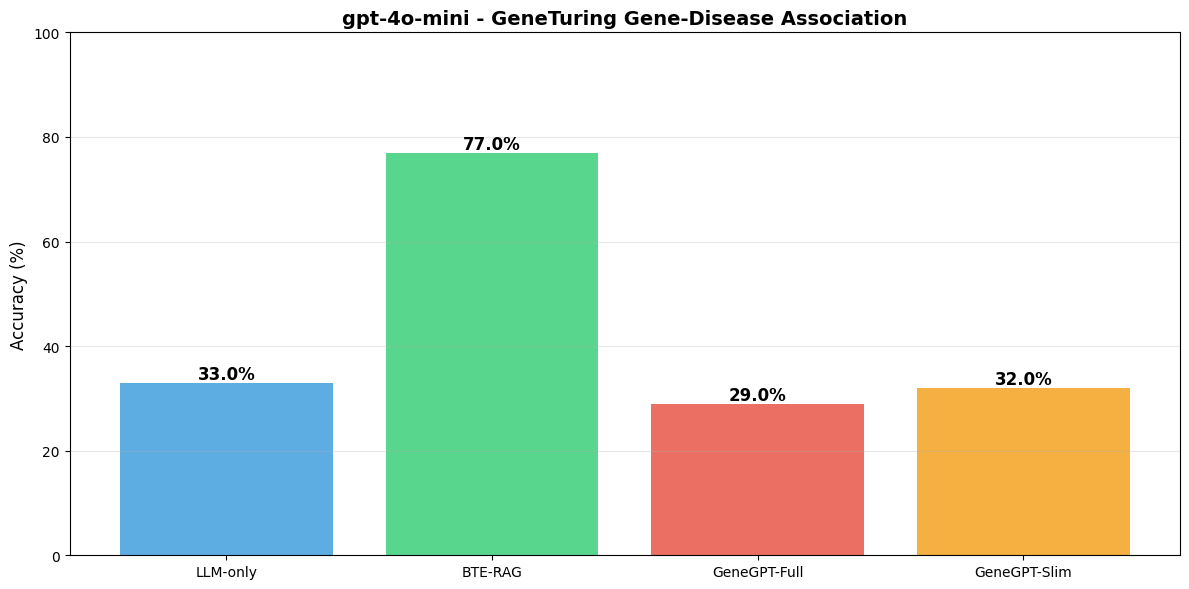

In [72]:
# LLM-only
gpt4omini_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_mini_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_llm = extract_gene_prediction(gpt4omini_prompt, output_col="llm_answer_prompt_test")
evaluated_df_llm_4omini, metrics_llm_4omini = compare_predictions_to_gold(gpt4omini_llm, pred_col="predicted_gene")

# BTE-RAG
gpt4omini_rag = pd.read_csv("data/geneTuring/results/gpt_4o_mini_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_rag = extract_gene_prediction(gpt4omini_rag, output_col="output_NC")
evaluated_df_rag_4omini, metrics_rag_4omini = compare_predictions_to_gold(gpt4omini_rag)

# GeneGPT (full)
df_genegpt_4omini_full = dfs["data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4omini_genegpt_full.json"]

# GeneGPT (slim)
df_genegpt_4omini_slim = dfs["data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4omini_genegpt_slim.json"]

# Compare
comparison_4omini = compare_all_methods_geneTuring(
    df_llm=gpt4omini_llm,
    df_rag=gpt4omini_rag,
    df_genegpt_full=df_genegpt_4omini_full,
    df_genegpt_slim=df_genegpt_4omini_slim,
    model_name="gpt-4o-mini",
    metrics_llm=metrics_llm_4omini,
    metrics_rag=metrics_rag_4omini,
    save_dir=None
)



Model: gpt-4o - GeneTuring Gene-Disease Association
         Method  Accuracy  Count
0      LLM-only      56.0    100
1       BTE-RAG      80.0    100
2  GeneGPT-Full      59.0    100
3  GeneGPT-Slim      64.0    100



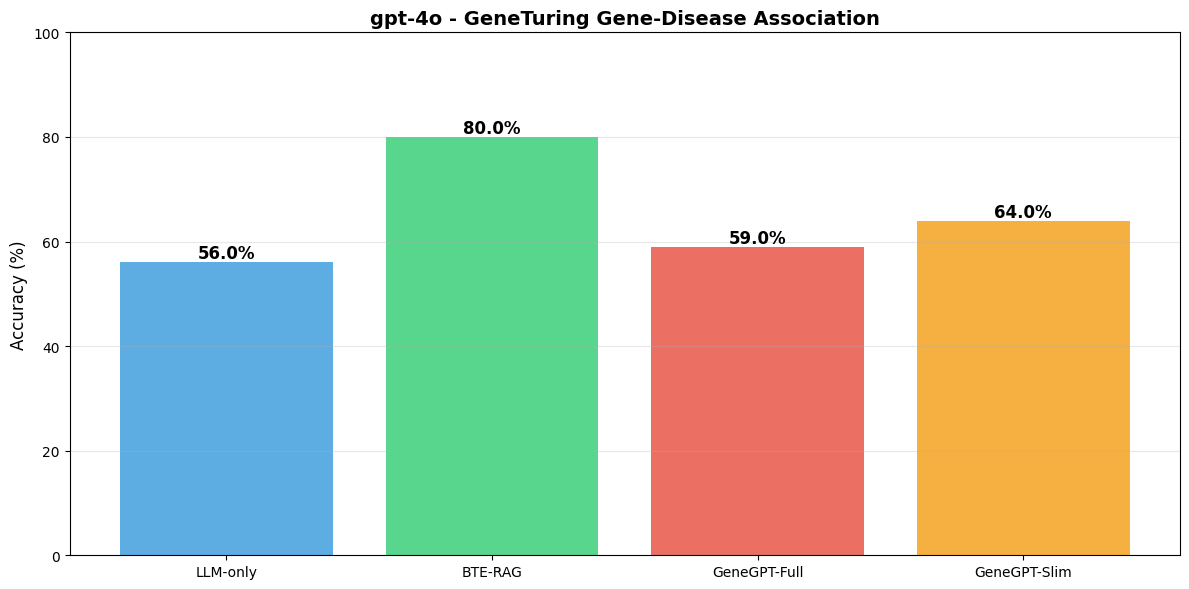

In [73]:
# GPT-4o Comparison

# LLM-only
gpt4o_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_llm = extract_gene_prediction(gpt4o_prompt, output_col="llm_answer_prompt_test")
evaluated_df_llm_4o, metrics_llm_4o = compare_predictions_to_gold(gpt4o_llm, pred_col="predicted_gene")

# BTE-RAG
gpt4o_rag = pd.read_csv("data/geneTuring/results/gpt_4o_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_rag = extract_gene_prediction(gpt4o_rag, output_col="output_NC")
evaluated_df_rag_4o, metrics_rag_4o = compare_predictions_to_gold(gpt4o_rag)

# GeneGPT (full)
df_genegpt_4o_full = dfs["data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4o_genegpt_full.json"]

# GeneGPT (slim)
df_genegpt_4o_slim = dfs["data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4o_genegpt_slim.json"]

# Compare
comparison_4o = compare_all_methods_geneTuring(
    df_llm=gpt4o_llm,
    df_rag=gpt4o_rag,
    df_genegpt_full=df_genegpt_4o_full,
    df_genegpt_slim=df_genegpt_4o_slim,
    model_name="gpt-4o",
    metrics_llm=metrics_llm_4o,
    metrics_rag=metrics_rag_4o,
    save_dir=None
)

### combined plot

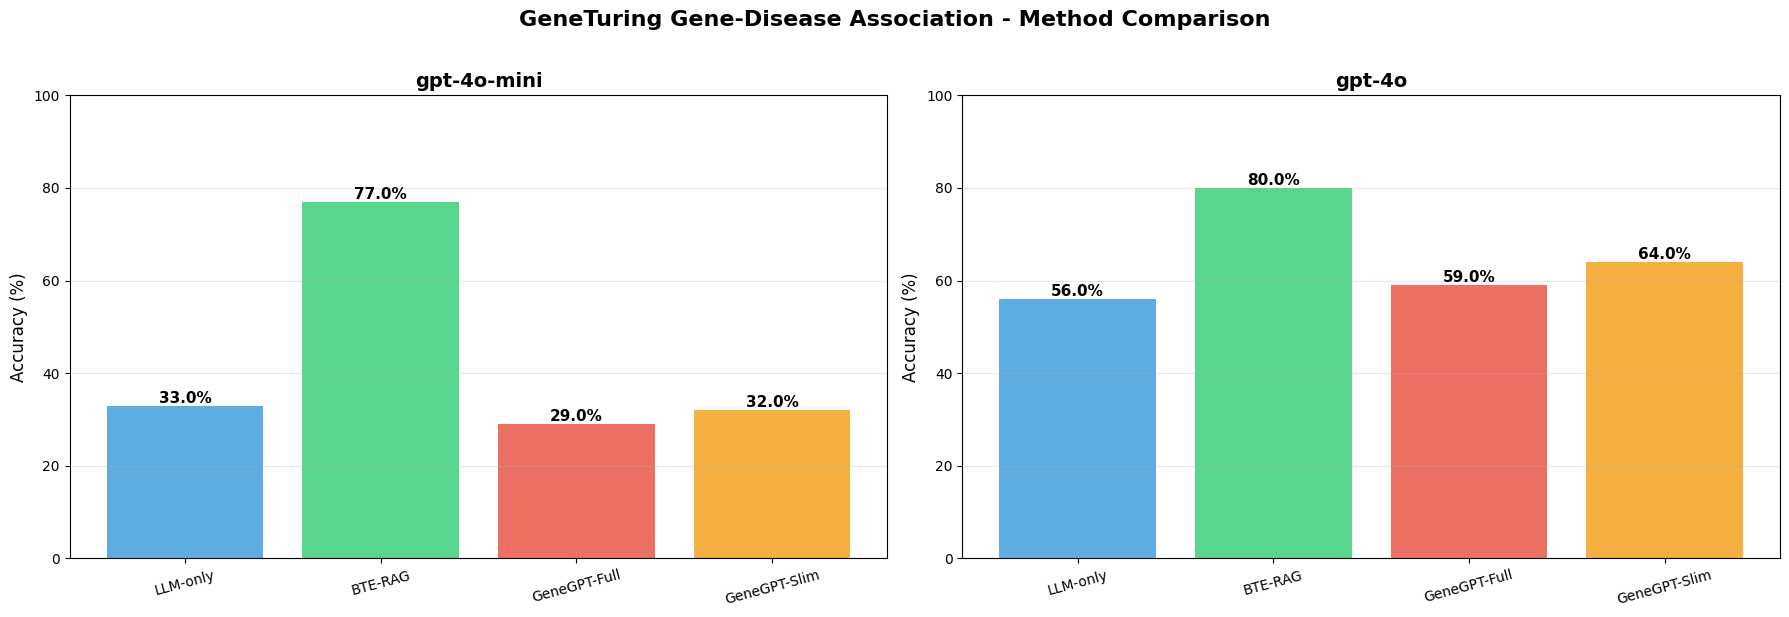

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (comparison, model) in enumerate([
    (comparison_4omini, "gpt-4o-mini"),
    (comparison_4o, "gpt-4o")
]):
    ax = axes[idx]
    bars = ax.bar(comparison['Method'], comparison['Accuracy'],
                   color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'], alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{model}', fontsize=14, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('GeneTuring Gene-Disease Association - Method Comparison', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('figures/geneTuring_gene_disease/combined_geneTuring_comparison.png', 
#             dpi=300, bbox_inches='tight')
plt.show()

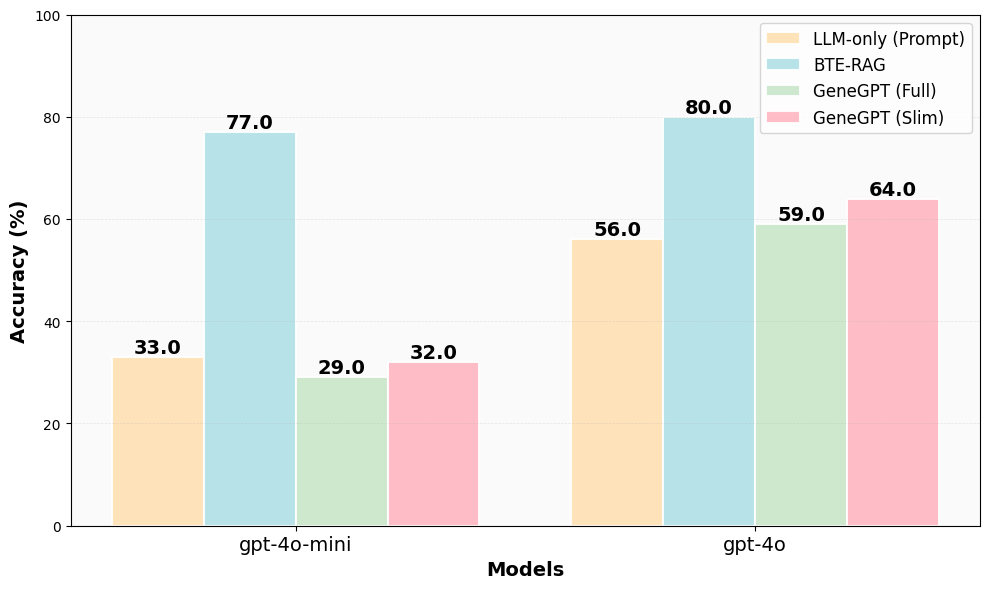

In [75]:
import matplotlib.pyplot as plt
import numpy as np

# Data setup
models = ['gpt-4o-mini', 'gpt-4o']
methods = ['LLM-only (Prompt)', 'BTE-RAG', 'GeneGPT (Full)', 'GeneGPT (Slim)']

# Extract accuracy values for each model
gpt_4o_mini_accuracies = comparison_4omini['Accuracy'].values
gpt_4o_accuracies = comparison_4o['Accuracy'].values

# Pastel color palette
colors = ['#FFE0B2', '#B0E0E6', '#C8E6C9','#FFB6C1' ]  
# pastel pink, blue, green, orange

fig, ax = plt.subplots(figsize=(10, 6))

bar_width = 0.2
x = np.arange(len(models))

for i, method in enumerate(methods):
    accuracies = [gpt_4o_mini_accuracies[i], gpt_4o_accuracies[i]]
    bars = ax.bar(x + i * bar_width, accuracies, bar_width, 
                   label=method, color=colors[i], alpha=0.9, edgecolor='white', linewidth=1.5)
    
    # accuracy values on top of bars
    for j, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Plot
ax.set_ylabel('Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Models', fontsize=14, fontweight='bold')
# ax.set_title('GeneTuring Gene-Disease Association - Method Comparison', 
#              fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(models, fontsize=14)
ax.set_ylim(0, 100)
ax.legend(loc='upper right', frameon=True, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig("figures/geneTuring_gene_disease/combined_geneTuring_comparison.png", dpi=400, bbox_inches="tight")
plt.show()

# Stats

In [77]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

def calculate_wilson_ci(n_correct, n_total, confidence=0.95):
    """
    Calculate Wilson confidence interval for accuracy
    
    Parameters:
    -----------
    n_correct : int
        Number of correct predictions
    n_total : int
        Total number of predictions
    confidence : float
        Confidence level (default 0.95 for 95% CI)
    
    Returns:
    --------
    tuple : (lower_bound, upper_bound) as percentages
    """
    ci_low, ci_high = proportion_confint(
        n_correct, n_total, 
        alpha=1-confidence, 
        method='wilson'
    )
    return ci_low * 100, ci_high * 100


def add_ci_to_metrics(df, pred_col="predicted_gene", gold_col="Goldstandard"):
    """
    Add Wilson CI to existing metrics for LLM-only and BTE-RAG
    """
    df = df.copy()
    
    # Normalize both gold and predicted
    df["Goldstandard_norm"] = (
        df[gold_col]
        .astype(str)
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
    )
    df["Pred_norm"] = (
        df[pred_col]
        .astype(str)
        .str.upper()
        .str.replace(r"\s+", "", regex=True)
    )
    
    # Correct if prediction appears within comma-separated gold list
    df["correct"] = df.apply(
        lambda row: (
            isinstance(row["Pred_norm"], str)
            and row["Pred_norm"] in row["Goldstandard_norm"].split(",")
        ),
        axis=1,
    )
    
    n_correct = df["correct"].sum()
    n_total = len(df)
    accuracy = (n_correct / n_total) * 100
    
    ci_low, ci_high = calculate_wilson_ci(n_correct, n_total)
    
    return {
        'n_correct': n_correct,
        'n_total': n_total,
        'accuracy': accuracy,
        'ci_lower': ci_low,
        'ci_upper': ci_high
    }


def add_ci_to_genegpt(df):
    """
    Add Wilson CI to GeneGPT results
    """
    n_correct = df['is_correct'].sum()
    n_total = len(df)
    accuracy = (n_correct / n_total) * 100
    
    ci_low, ci_high = calculate_wilson_ci(n_correct, n_total)
    
    return {
        'n_correct': n_correct,
        'n_total': n_total,
        'accuracy': accuracy,
        'ci_lower': ci_low,
        'ci_upper': ci_high
    }


# ============================================================================
# CALCULATE CI FOR ALL METHODS - GPT-4o-mini
# ============================================================================

print("="*80)
print("GPT-4o-mini Methods with 95% Wilson CI")
print("="*80)

# LLM-only (GPT-4o-mini)
gpt4omini_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_mini_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_llm_df = extract_gene_prediction(gpt4omini_prompt, output_col="llm_answer_prompt_test")
llm_mini_stats = add_ci_to_metrics(gpt4omini_llm_df, pred_col="predicted_gene")

print(f"\nLLM-only (GPT-4o-mini):")
print(f"  Accuracy: {llm_mini_stats['accuracy']:.2f}% ({llm_mini_stats['n_correct']}/{llm_mini_stats['n_total']})")
print(f"  Wilson 95% CI: [{llm_mini_stats['ci_lower']:.2f}%, {llm_mini_stats['ci_upper']:.2f}%]")

# BTE-RAG (GPT-4o-mini)
gpt4omini_rag = pd.read_csv("data/geneTuring/results/gpt_4o_mini_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4omini_rag_df = extract_gene_prediction(gpt4omini_rag, output_col="output_NC")
rag_mini_stats = add_ci_to_metrics(gpt4omini_rag_df)

print(f"\nBTE-RAG (GPT-4o-mini):")
print(f"  Accuracy: {rag_mini_stats['accuracy']:.2f}% ({rag_mini_stats['n_correct']}/{rag_mini_stats['n_total']})")
print(f"  Wilson 95% CI: [{rag_mini_stats['ci_lower']:.2f}%, {rag_mini_stats['ci_upper']:.2f}%]")

# GeneGPT-Full (GPT-4o-mini)
with open("data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4omini_genegpt_full.json") as f:
    genegpt_full_mini = json.load(f)
genegpt_full_mini_df = pd.DataFrame(genegpt_full_mini)
genegpt_full_mini_df['parsed_model_answer'] = genegpt_full_mini_df['model_answer'].apply(parse_model_answer)
genegpt_full_mini_df['gold_standard_list'] = genegpt_full_mini_df['gold_standard'].apply(
    lambda x: [gene.strip() for gene in str(x).split(',')]
)
def check_answer_flexible(row):
    if pd.isna(row['parsed_model_answer']) or row['parsed_model_answer'] == '':
        return False
    model_ans = str(row['parsed_model_answer']).strip().upper()
    gold_list = [g.strip().upper() for g in row['gold_standard_list']]
    return model_ans in gold_list
genegpt_full_mini_df['is_correct'] = genegpt_full_mini_df.apply(check_answer_flexible, axis=1)
genegpt_full_mini_stats = add_ci_to_genegpt(genegpt_full_mini_df)

print(f"\nGeneGPT-Full (GPT-4o-mini):")
print(f"  Accuracy: {genegpt_full_mini_stats['accuracy']:.2f}% ({genegpt_full_mini_stats['n_correct']}/{genegpt_full_mini_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_full_mini_stats['ci_lower']:.2f}%, {genegpt_full_mini_stats['ci_upper']:.2f}%]")

# GeneGPT-Slim (GPT-4o-mini)
with open("data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4omini_genegpt_slim.json") as f:
    genegpt_slim_mini = json.load(f)
genegpt_slim_mini_df = pd.DataFrame(genegpt_slim_mini)
genegpt_slim_mini_df['parsed_model_answer'] = genegpt_slim_mini_df['model_answer'].apply(parse_model_answer)
genegpt_slim_mini_df['gold_standard_list'] = genegpt_slim_mini_df['gold_standard'].apply(
    lambda x: [gene.strip() for gene in str(x).split(',')]
)
genegpt_slim_mini_df['is_correct'] = genegpt_slim_mini_df.apply(check_answer_flexible, axis=1)
genegpt_slim_mini_stats = add_ci_to_genegpt(genegpt_slim_mini_df)

print(f"\nGeneGPT-Slim (GPT-4o-mini):")
print(f"  Accuracy: {genegpt_slim_mini_stats['accuracy']:.2f}% ({genegpt_slim_mini_stats['n_correct']}/{genegpt_slim_mini_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_slim_mini_stats['ci_lower']:.2f}%, {genegpt_slim_mini_stats['ci_upper']:.2f}%]")

print("\n" + "="*80 + "\n")

# ============================================================================
# CALCULATE CI FOR ALL METHODS - GPT-4o
# ============================================================================

print("="*80)
print("GPT-4o Methods with 95% Wilson CI")
print("="*80)

# LLM-only (GPT-4o)
gpt4o_prompt = pd.read_csv("data/geneTuring/results/gpt_4o_PROMPT_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_llm_df = extract_gene_prediction(gpt4o_prompt, output_col="llm_answer_prompt_test")
llm_4o_stats = add_ci_to_metrics(gpt4o_llm_df, pred_col="predicted_gene")

print(f"\nLLM-only (GPT-4o):")
print(f"  Accuracy: {llm_4o_stats['accuracy']:.2f}% ({llm_4o_stats['n_correct']}/{llm_4o_stats['n_total']})")
print(f"  Wilson 95% CI: [{llm_4o_stats['ci_lower']:.2f}%, {llm_4o_stats['ci_upper']:.2f}%]")

# BTE-RAG (GPT-4o)
gpt4o_rag = pd.read_csv("data/geneTuring/results/gpt_4o_BTE-RAG_geneTuring_gene_dis_assoc_context_output.csv")
gpt4o_rag_df = extract_gene_prediction(gpt4o_rag, output_col="output_NC")
rag_4o_stats = add_ci_to_metrics(gpt4o_rag_df)

print(f"\nBTE-RAG (GPT-4o):")
print(f"  Accuracy: {rag_4o_stats['accuracy']:.2f}% ({rag_4o_stats['n_correct']}/{rag_4o_stats['n_total']})")
print(f"  Wilson 95% CI: [{rag_4o_stats['ci_lower']:.2f}%, {rag_4o_stats['ci_upper']:.2f}%]")

# GeneGPT-Full (GPT-4o)
with open("data/GeneGPT_results/111111/GeneTuring_gene_dis_gpt4o_genegpt_full.json") as f:
    genegpt_full_4o = json.load(f)
genegpt_full_4o_df = pd.DataFrame(genegpt_full_4o)
genegpt_full_4o_df['parsed_model_answer'] = genegpt_full_4o_df['model_answer'].apply(parse_model_answer)
genegpt_full_4o_df['gold_standard_list'] = genegpt_full_4o_df['gold_standard'].apply(
    lambda x: [gene.strip() for gene in str(x).split(',')]
)
genegpt_full_4o_df['is_correct'] = genegpt_full_4o_df.apply(check_answer_flexible, axis=1)
genegpt_full_4o_stats = add_ci_to_genegpt(genegpt_full_4o_df)

print(f"\nGeneGPT-Full (GPT-4o):")
print(f"  Accuracy: {genegpt_full_4o_stats['accuracy']:.2f}% ({genegpt_full_4o_stats['n_correct']}/{genegpt_full_4o_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_full_4o_stats['ci_lower']:.2f}%, {genegpt_full_4o_stats['ci_upper']:.2f}%]")

# GeneGPT-Slim (GPT-4o)
with open("data/GeneGPT_results/001001/GeneTuring_gene_dis_gpt4o_genegpt_slim.json") as f:
    genegpt_slim_4o = json.load(f)
genegpt_slim_4o_df = pd.DataFrame(genegpt_slim_4o)
genegpt_slim_4o_df['parsed_model_answer'] = genegpt_slim_4o_df['model_answer'].apply(parse_model_answer)
genegpt_slim_4o_df['gold_standard_list'] = genegpt_slim_4o_df['gold_standard'].apply(
    lambda x: [gene.strip() for gene in str(x).split(',')]
)
genegpt_slim_4o_df['is_correct'] = genegpt_slim_4o_df.apply(check_answer_flexible, axis=1)
genegpt_slim_4o_stats = add_ci_to_genegpt(genegpt_slim_4o_df)

print(f"\nGeneGPT-Slim (GPT-4o):")
print(f"  Accuracy: {genegpt_slim_4o_stats['accuracy']:.2f}% ({genegpt_slim_4o_stats['n_correct']}/{genegpt_slim_4o_stats['n_total']})")
print(f"  Wilson 95% CI: [{genegpt_slim_4o_stats['ci_lower']:.2f}%, {genegpt_slim_4o_stats['ci_upper']:.2f}%]")

print("\n" + "="*80 + "\n")

# ============================================================================
# CREATE COMPREHENSIVE SUMMARY TABLE
# ============================================================================

summary_data = {
    'Model': ['gpt-4o-mini', 'gpt-4o-mini', 'gpt-4o-mini', 'gpt-4o-mini',
              'gpt-4o', 'gpt-4o', 'gpt-4o', 'gpt-4o'],
    'Method': ['LLM-only', 'BTE-RAG', 'GeneGPT-Full', 'GeneGPT-Slim',
               'LLM-only', 'BTE-RAG', 'GeneGPT-Full', 'GeneGPT-Slim'],
    'Accuracy': [
        llm_mini_stats['accuracy'], rag_mini_stats['accuracy'], 
        genegpt_full_mini_stats['accuracy'], genegpt_slim_mini_stats['accuracy'],
        llm_4o_stats['accuracy'], rag_4o_stats['accuracy'],
        genegpt_full_4o_stats['accuracy'], genegpt_slim_4o_stats['accuracy']
    ],
    'CI_Lower': [
        llm_mini_stats['ci_lower'], rag_mini_stats['ci_lower'],
        genegpt_full_mini_stats['ci_lower'], genegpt_slim_mini_stats['ci_lower'],
        llm_4o_stats['ci_lower'], rag_4o_stats['ci_lower'],
        genegpt_full_4o_stats['ci_lower'], genegpt_slim_4o_stats['ci_lower']
    ],
    'CI_Upper': [
        llm_mini_stats['ci_upper'], rag_mini_stats['ci_upper'],
        genegpt_full_mini_stats['ci_upper'], genegpt_slim_mini_stats['ci_upper'],
        llm_4o_stats['ci_upper'], rag_4o_stats['ci_upper'],
        genegpt_full_4o_stats['ci_upper'], genegpt_slim_4o_stats['ci_upper']
    ],
    'N': [
        llm_mini_stats['n_total'], rag_mini_stats['n_total'],
        genegpt_full_mini_stats['n_total'], genegpt_slim_mini_stats['n_total'],
        llm_4o_stats['n_total'], rag_4o_stats['n_total'],
        genegpt_full_4o_stats['n_total'], genegpt_slim_4o_stats['n_total']
    ]
}

summary_df = pd.DataFrame(summary_data)

print("="*100)
print("COMPREHENSIVE SUMMARY - GeneTuring Gene-Disease Association with 95% Wilson CI")
print("="*100)
print(f"{'Model':<15} {'Method':<18} {'Accuracy':<12} {'N':<6} {'Wilson 95% CI':<25}")
print("-"*100)

for _, row in summary_df.iterrows():
    print(f"{row['Model']:<15} "
          f"{row['Method']:<18} "
          f"{row['Accuracy']:>6.2f}%    "
          f"{row['N']:<6.0f} "
          f"[{row['CI_Lower']:>5.2f}%, {row['CI_Upper']:>5.2f}%]")

print("="*100 + "\n")

# Save to CSV
# summary_df.to_csv('geneturing_all_methods_with_ci.csv', index=False)
print("Summary saved to: geneturing_all_methods_with_ci.csv\n")

GPT-4o-mini Methods with 95% Wilson CI

LLM-only (GPT-4o-mini):
  Accuracy: 33.00% (33/100)
  Wilson 95% CI: [24.56%, 42.69%]

BTE-RAG (GPT-4o-mini):
  Accuracy: 77.00% (77/100)
  Wilson 95% CI: [67.85%, 84.16%]

GeneGPT-Full (GPT-4o-mini):
  Accuracy: 29.00% (29/100)
  Wilson 95% CI: [21.01%, 38.54%]

GeneGPT-Slim (GPT-4o-mini):
  Accuracy: 32.00% (32/100)
  Wilson 95% CI: [23.67%, 41.66%]


GPT-4o Methods with 95% Wilson CI

LLM-only (GPT-4o):
  Accuracy: 56.00% (56/100)
  Wilson 95% CI: [46.23%, 65.33%]

BTE-RAG (GPT-4o):
  Accuracy: 80.00% (80/100)
  Wilson 95% CI: [71.12%, 86.66%]

GeneGPT-Full (GPT-4o):
  Accuracy: 59.00% (59/100)
  Wilson 95% CI: [49.20%, 68.13%]

GeneGPT-Slim (GPT-4o):
  Accuracy: 64.00% (64/100)
  Wilson 95% CI: [54.24%, 72.73%]


COMPREHENSIVE SUMMARY - GeneTuring Gene-Disease Association with 95% Wilson CI
Model           Method             Accuracy     N      Wilson 95% CI            
-------------------------------------------------------------------------

In [78]:
import numpy as np
from scipy.stats import chi2
from statsmodels.stats.contingency_tables import mcnemar

def newcombe_ci(n1_correct, n1_total, n2_correct, n2_total, confidence=0.95):
    """
    Calculate Newcombe hybrid score confidence interval for difference between two proportions
    
    Parameters:
    -----------
    n1_correct : int
        Number of correct predictions for method 1
    n1_total : int
        Total predictions for method 1
    n2_correct : int
        Number of correct predictions for method 2
    n2_total : int
        Total predictions for method 2
    confidence : float
        Confidence level (default 0.95)
    
    Returns:
    --------
    dict with:
        - diff: difference in proportions (p1 - p2) as percentage
        - ci_lower: lower bound of CI for difference
        - ci_upper: upper bound of CI for difference
        - p1, p2: individual proportions
    """
    from statsmodels.stats.proportion import proportion_confint
    
    # Calculate proportions
    p1 = n1_correct / n1_total
    p2 = n2_correct / n2_total
    diff = (p1 - p2) * 100
    
    # Get Wilson CIs for each proportion
    l1, u1 = proportion_confint(n1_correct, n1_total, alpha=1-confidence, method='wilson')
    l2, u2 = proportion_confint(n2_correct, n2_total, alpha=1-confidence, method='wilson')
    
    # Newcombe hybrid score interval for difference
    # Lower bound: (p1 - p2) - sqrt((p1 - l1)^2 + (u2 - p2)^2)
    # Upper bound: (p1 - p2) + sqrt((u1 - p1)^2 + (p2 - l2)^2)
    
    ci_lower = (p1 - p2) - np.sqrt((p1 - l1)**2 + (u2 - p2)**2)
    ci_upper = (p1 - p2) + np.sqrt((u1 - p1)**2 + (p2 - l2)**2)
    
    return {
        'p1': p1 * 100,
        'p2': p2 * 100,
        'diff': diff,
        'ci_lower': ci_lower * 100,
        'ci_upper': ci_upper * 100
    }


def mcnemar_test_paired(df1, df2, method1_name, method2_name):
    """
    Perform McNemar's test for paired data (same test questions)
    
    Parameters:
    -----------
    df1, df2 : DataFrames
        Must have 'correct' or 'is_correct' column and same length
    method1_name, method2_name : str
        Names for display
    
    Returns:
    --------
    dict with test results
    """
    # Ensure same length
    assert len(df1) == len(df2), f"DataFrames must have same length. Got {len(df1)} and {len(df2)}"
    
    # Get correctness columns (handle both column names)
    if 'correct' in df1.columns:
        correct1 = df1['correct'].values
    elif 'is_correct' in df1.columns:
        correct1 = df1['is_correct'].values
    else:
        raise ValueError("df1 must have 'correct' or 'is_correct' column")
    
    if 'correct' in df2.columns:
        correct2 = df2['correct'].values
    elif 'is_correct' in df2.columns:
        correct2 = df2['is_correct'].values
    else:
        raise ValueError("df2 must have 'correct' or 'is_correct' column")
    
    # Create contingency table
    both_correct = (correct1 & correct2).sum()
    method1_only = (correct1 & ~correct2).sum()
    method2_only = (~correct1 & correct2).sum()
    both_wrong = (~correct1 & ~correct2).sum()
    
    # Contingency table for McNemar's test
    # Format: [[both_correct, method1_correct_method2_wrong],
    #          [method1_wrong_method2_correct, both_wrong]]
    contingency_table = np.array([[both_correct, method1_only],
                                   [method2_only, both_wrong]])
    
    print(f"\n{'='*80}")
    print(f"McNemar's Test: {method1_name} vs {method2_name}")
    print(f"{'='*80}")
    print(f"\nContingency Table:")
    print(f"{'':30} {method2_name} Correct    {method2_name} Wrong")
    print(f"{method1_name} Correct:     {both_correct:6d}            {method1_only:6d}")
    print(f"{method1_name} Wrong:       {method2_only:6d}            {both_wrong:6d}")
    
    # McNemar's test
    # Use exact test if sum of discordant pairs < 25, otherwise continuity correction
    use_exact = (method1_only + method2_only) < 25
    
    result = mcnemar(contingency_table, exact=use_exact, correction=not use_exact)
    
    print(f"\nDiscordant pairs: {method1_only + method2_only}")
    print(f"  {method1_name} correct, {method2_name} wrong: {method1_only}")
    print(f"  {method1_name} wrong, {method2_name} correct: {method2_only}")
    print(f"\nMcNemar's statistic: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.6f}")
    
    if result.pvalue < 0.001:
        sig_str = "p < 0.001 ***"
        interpretation = "HIGHLY SIGNIFICANT"
    elif result.pvalue < 0.01:
        sig_str = "p < 0.01 **"
        interpretation = "VERY SIGNIFICANT"
    elif result.pvalue < 0.05:
        sig_str = "p < 0.05 *"
        interpretation = "SIGNIFICANT"
    else:
        sig_str = "not significant (p ≥ 0.05)"
        interpretation = "NOT SIGNIFICANT"
    
    print(f"Result: {sig_str}")
    print(f"Interpretation: {interpretation}")
    
    # Determine which method is better
    if method1_only > method2_only:
        better = method1_name
    elif method2_only > method1_only:
        better = method2_name
    else:
        better = "TIE"
    
    print(f"Better method: {better}")
    print(f"{'='*80}\n")
    
    return {
        'method1': method1_name,
        'method2': method2_name,
        'both_correct': both_correct,
        'method1_only': method1_only,
        'method2_only': method2_only,
        'both_wrong': both_wrong,
        'statistic': result.statistic,
        'pvalue': result.pvalue,
        'significant': result.pvalue < 0.05,
        'better_method': better
    }




In [79]:
gpt4omini_llm_eval = evaluated_df_llm_4omini
gpt4o_llm_eval     = evaluated_df_llm_4o

gpt4omini_rag_eval = evaluated_df_rag_4omini
gpt4o_rag_eval     = evaluated_df_rag_4o

In [81]:
df_full_4omini = df_genegpt_4omini_full.copy()
df_slim_4omini = df_genegpt_4omini_slim.copy()
df_full_4o     = df_genegpt_4o_full.copy()
df_slim_4o     = df_genegpt_4o_slim.copy()

# Ensure they have a 'correct' column (McNemar helper expects 'correct' or 'is_correct')
for _df in [df_full_4omini, df_slim_4omini, df_full_4o, df_slim_4o]:
    if "correct" not in _df.columns:
        if "is_correct" in _df.columns:
            _df["correct"] = _df["is_correct"].astype(bool)
        else:
            raise ValueError("GeneGPT df missing 'is_correct' (and 'correct').")

In [82]:
# ============================================================================
# PAIRWISE COMPARISONS - GPT-4o-mini
# ============================================================================

print("\n" + "#"*80)
print("PAIRWISE COMPARISONS FOR GPT-4o-mini")
print("#"*80 + "\n")

# Comparison 1: BTE-RAG vs LLM-only (GPT-4o-mini) - SWAPPED ORDER
print("="*80)
print("1. BTE-RAG vs LLM-only (GPT-4o-mini)")
print("="*80)

newcombe_1 = newcombe_ci(
    rag_mini_stats['n_correct'], rag_mini_stats['n_total'],  # BTE-RAG first
    llm_mini_stats['n_correct'], llm_mini_stats['n_total']   # LLM-only second
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_1['p1']:.2f}%")
print(f"  LLM-only accuracy: {newcombe_1['p2']:.2f}%")
print(f"  Difference (BTE-RAG - LLM-only): {newcombe_1['diff']:.2f}%")
print(f"  95% CI: [{newcombe_1['ci_lower']:.2f}%, {newcombe_1['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_1['diff']:.2f} percentage points")

mcnemar_1 = mcnemar_test_paired(
    gpt4omini_rag_eval,  # BTE-RAG first
    gpt4omini_llm_eval,  # LLM-only second
    'BTE-RAG', 'LLM-only'
)

# Comparison 2: BTE-RAG vs GeneGPT-Full (GPT-4o-mini)
print("\n" + "="*80)
print("2. BTE-RAG vs GeneGPT-Full (GPT-4o-mini)")
print("="*80)

newcombe_2 = newcombe_ci(
    rag_mini_stats['n_correct'], rag_mini_stats['n_total'],
    genegpt_full_mini_stats['n_correct'], genegpt_full_mini_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_2['p1']:.2f}%")
print(f"  GeneGPT-Full accuracy: {newcombe_2['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Full): {newcombe_2['diff']:.2f}%")
print(f"  95% CI: [{newcombe_2['ci_lower']:.2f}%, {newcombe_2['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_2['diff']:.2f} percentage points")

mcnemar_2 = mcnemar_test_paired(
    gpt4omini_rag_eval,  # has 'correct' column
    df_full_4omini,      # has 'is_correct' column
    'BTE-RAG', 'GeneGPT-Full'
)

# Comparison 3: BTE-RAG vs GeneGPT-Slim (GPT-4o-mini)
print("\n" + "="*80)
print("3. BTE-RAG vs GeneGPT-Slim (GPT-4o-mini)")
print("="*80)

newcombe_3 = newcombe_ci(
    rag_mini_stats['n_correct'], rag_mini_stats['n_total'],
    genegpt_slim_mini_stats['n_correct'], genegpt_slim_mini_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_3['p1']:.2f}%")
print(f"  GeneGPT-Slim accuracy: {newcombe_3['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Slim): {newcombe_3['diff']:.2f}%")
print(f"  95% CI: [{newcombe_3['ci_lower']:.2f}%, {newcombe_3['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_3['diff']:.2f} percentage points")

mcnemar_3 = mcnemar_test_paired(
    gpt4omini_rag_eval,  # has 'correct' column
    df_slim_4omini,      # has 'is_correct' column
    'BTE-RAG', 'GeneGPT-Slim'
)

# ============================================================================
# PAIRWISE COMPARISONS - GPT-4o
# ============================================================================

print("\n" + "#"*80)
print("PAIRWISE COMPARISONS FOR GPT-4o")
print("#"*80 + "\n")

# Comparison 4: BTE-RAG vs LLM-only (GPT-4o) - SWAPPED ORDER
print("="*80)
print("4. BTE-RAG vs LLM-only (GPT-4o)")
print("="*80)

newcombe_4 = newcombe_ci(
    rag_4o_stats['n_correct'], rag_4o_stats['n_total'],  # BTE-RAG first
    llm_4o_stats['n_correct'], llm_4o_stats['n_total']   # LLM-only second
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_4['p1']:.2f}%")
print(f"  LLM-only accuracy: {newcombe_4['p2']:.2f}%")
print(f"  Difference (BTE-RAG - LLM-only): {newcombe_4['diff']:.2f}%")
print(f"  95% CI: [{newcombe_4['ci_lower']:.2f}%, {newcombe_4['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_4['diff']:.2f} percentage points")

mcnemar_4 = mcnemar_test_paired(
    gpt4o_rag_eval,  # BTE-RAG first
    gpt4o_llm_eval,  # LLM-only second
    'BTE-RAG', 'LLM-only'
)

# Comparison 5: BTE-RAG vs GeneGPT-Full (GPT-4o)
print("\n" + "="*80)
print("5. BTE-RAG vs GeneGPT-Full (GPT-4o)")
print("="*80)

newcombe_5 = newcombe_ci(
    rag_4o_stats['n_correct'], rag_4o_stats['n_total'],
    genegpt_full_4o_stats['n_correct'], genegpt_full_4o_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_5['p1']:.2f}%")
print(f"  GeneGPT-Full accuracy: {newcombe_5['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Full): {newcombe_5['diff']:.2f}%")
print(f"  95% CI: [{newcombe_5['ci_lower']:.2f}%, {newcombe_5['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_5['diff']:.2f} percentage points")

mcnemar_5 = mcnemar_test_paired(
    gpt4o_rag_eval,  # has 'correct' column
    df_full_4o,      # has 'is_correct' column
    'BTE-RAG', 'GeneGPT-Full'
)

# Comparison 6: BTE-RAG vs GeneGPT-Slim (GPT-4o)
print("\n" + "="*80)
print("6. BTE-RAG vs GeneGPT-Slim (GPT-4o)")
print("="*80)

newcombe_6 = newcombe_ci(
    rag_4o_stats['n_correct'], rag_4o_stats['n_total'],
    genegpt_slim_4o_stats['n_correct'], genegpt_slim_4o_stats['n_total']
)

print(f"\nNewcombe 95% CI for Difference:")
print(f"  BTE-RAG accuracy: {newcombe_6['p1']:.2f}%")
print(f"  GeneGPT-Slim accuracy: {newcombe_6['p2']:.2f}%")
print(f"  Difference (BTE-RAG - GeneGPT-Slim): {newcombe_6['diff']:.2f}%")
print(f"  95% CI: [{newcombe_6['ci_lower']:.2f}%, {newcombe_6['ci_upper']:.2f}%]")
print(f"  Interpretation: BTE-RAG is better by {newcombe_6['diff']:.2f} percentage points")

mcnemar_6 = mcnemar_test_paired(
    gpt4o_rag_eval,  # has 'correct' column
    df_slim_4o,      # has 'is_correct' column
    'BTE-RAG', 'GeneGPT-Slim'
)

# ============================================================================
# SUMMARY TABLE OF ALL COMPARISONS
# ============================================================================

comparison_summary = pd.DataFrame([
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs LLM-only',  # Updated
        'Method1_Acc': newcombe_1['p1'],
        'Method2_Acc': newcombe_1['p2'],
        'Difference': newcombe_1['diff'],
        'Newcombe_CI': f"[{newcombe_1['ci_lower']:.2f}, {newcombe_1['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_1['pvalue'],
        'Significant': 'Yes' if mcnemar_1['significant'] else 'No',
        'Better': mcnemar_1['better_method']
    },
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs GeneGPT-Full',
        'Method1_Acc': newcombe_2['p1'],
        'Method2_Acc': newcombe_2['p2'],
        'Difference': newcombe_2['diff'],
        'Newcombe_CI': f"[{newcombe_2['ci_lower']:.2f}, {newcombe_2['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_2['pvalue'],
        'Significant': 'Yes' if mcnemar_2['significant'] else 'No',
        'Better': mcnemar_2['better_method']
    },
    {
        'Model': 'GPT-4o-mini',
        'Comparison': 'BTE-RAG vs GeneGPT-Slim',
        'Method1_Acc': newcombe_3['p1'],
        'Method2_Acc': newcombe_3['p2'],
        'Difference': newcombe_3['diff'],
        'Newcombe_CI': f"[{newcombe_3['ci_lower']:.2f}, {newcombe_3['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_3['pvalue'],
        'Significant': 'Yes' if mcnemar_3['significant'] else 'No',
        'Better': mcnemar_3['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs LLM-only',  # Updated
        'Method1_Acc': newcombe_4['p1'],
        'Method2_Acc': newcombe_4['p2'],
        'Difference': newcombe_4['diff'],
        'Newcombe_CI': f"[{newcombe_4['ci_lower']:.2f}, {newcombe_4['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_4['pvalue'],
        'Significant': 'Yes' if mcnemar_4['significant'] else 'No',
        'Better': mcnemar_4['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs GeneGPT-Full',
        'Method1_Acc': newcombe_5['p1'],
        'Method2_Acc': newcombe_5['p2'],
        'Difference': newcombe_5['diff'],
        'Newcombe_CI': f"[{newcombe_5['ci_lower']:.2f}, {newcombe_5['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_5['pvalue'],
        'Significant': 'Yes' if mcnemar_5['significant'] else 'No',
        'Better': mcnemar_5['better_method']
    },
    {
        'Model': 'GPT-4o',
        'Comparison': 'BTE-RAG vs GeneGPT-Slim',
        'Method1_Acc': newcombe_6['p1'],
        'Method2_Acc': newcombe_6['p2'],
        'Difference': newcombe_6['diff'],
        'Newcombe_CI': f"[{newcombe_6['ci_lower']:.2f}, {newcombe_6['ci_upper']:.2f}]",
        'McNemar_p': mcnemar_6['pvalue'],
        'Significant': 'Yes' if mcnemar_6['significant'] else 'No',
        'Better': mcnemar_6['better_method']
    }
])

print("\n" + "="*120)
print("COMPREHENSIVE PAIRWISE COMPARISON SUMMARY")
print("="*120)
print(comparison_summary.to_string(index=False))
print("="*120 + "\n")

# Save to CSV
# comparison_summary.to_csv('geneturing_pairwise_comparisons.csv', index=False)
print("Pairwise comparison results saved to: geneturing_pairwise_comparisons.csv\n")


################################################################################
PAIRWISE COMPARISONS FOR GPT-4o-mini
################################################################################

1. BTE-RAG vs LLM-only (GPT-4o-mini)

Newcombe 95% CI for Difference:
  BTE-RAG accuracy: 77.00%
  LLM-only accuracy: 33.00%
  Difference (BTE-RAG - LLM-only): 44.00%
  95% CI: [30.67%, 55.06%]
  Interpretation: BTE-RAG is better by 44.00 percentage points

McNemar's Test: BTE-RAG vs LLM-only

Contingency Table:
                               LLM-only Correct    LLM-only Wrong
BTE-RAG Correct:         32                45
BTE-RAG Wrong:            1                22

Discordant pairs: 46
  BTE-RAG correct, LLM-only wrong: 45
  BTE-RAG wrong, LLM-only correct: 1

McNemar's statistic: 40.1957
P-value: 0.000000
Result: p < 0.001 ***
Interpretation: HIGHLY SIGNIFICANT
Better method: BTE-RAG


2. BTE-RAG vs GeneGPT-Full (GPT-4o-mini)

Newcombe 95% CI for Difference:
  BTE-RAG accuracy: 77.00%

In [83]:
def p_to_stars(p):
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "ns"

def add_sig_bracket(ax, x1, x2, y, h, text, fontsize=12, lw=1.5):
    """
    Draw a significance bracket between x1 and x2 at height y, with bracket height h.
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c="black")
    ax.text((x1 + x2) / 2, y + h, text, ha="center", va="bottom", fontsize=fontsize)

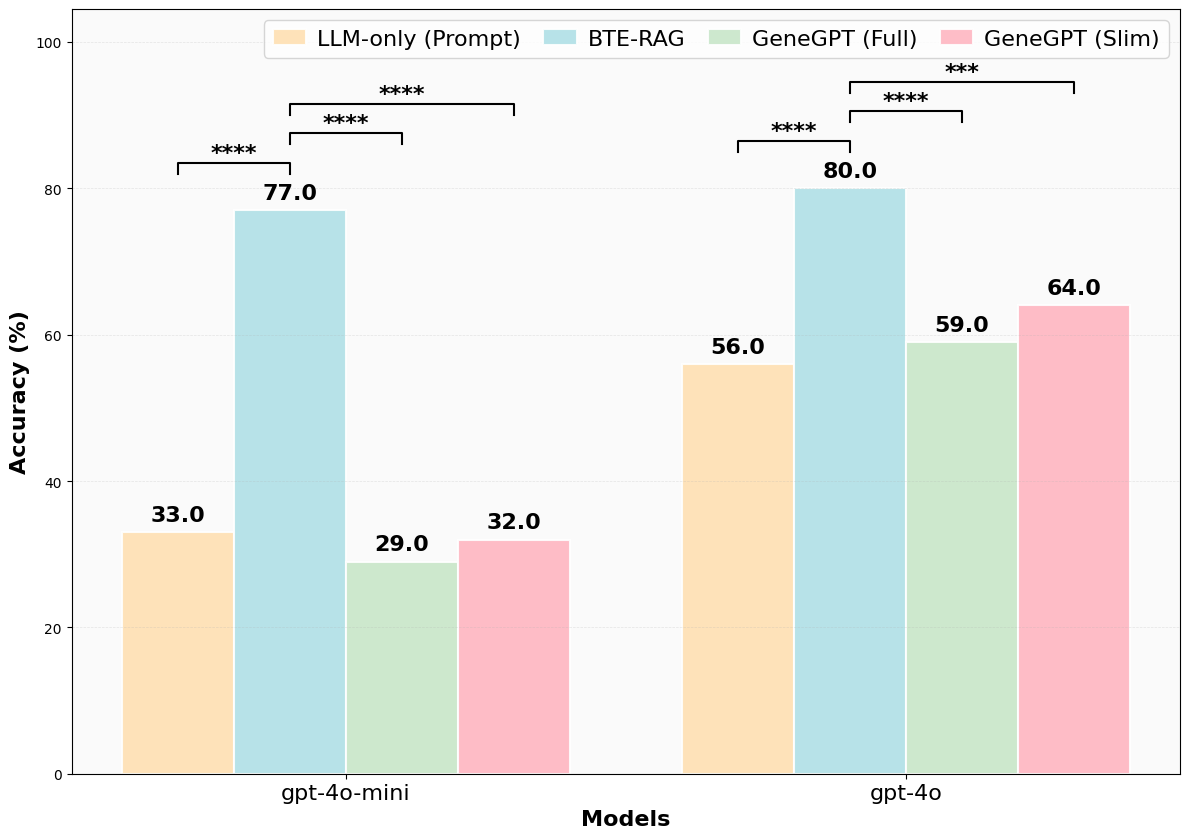

In [86]:
models  = ['gpt-4o-mini', 'gpt-4o']
methods = ['LLM-only (Prompt)', 'BTE-RAG', 'GeneGPT (Full)', 'GeneGPT (Slim)']
gpt_4o_mini_accuracies = comparison_4omini['Accuracy'].values
gpt_4o_accuracies      = comparison_4o['Accuracy'].values

# Pastel colors
colors = ['#FFE0B2', '#B0E0E6', '#C8E6C9', '#FFB6C1']  # orange, blue, green, pink

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 8.5))  # Increased height
bar_width = 0.2
x = np.arange(len(models))

# Store bar centers and tops for precise bracket placement
bar_centers = {}  # (model_idx, method_idx) -> x_center
bar_tops    = {}  # (model_idx, method_idx) -> y_top

for method_idx, method in enumerate(methods):
    accuracies = [gpt_4o_mini_accuracies[method_idx], gpt_4o_accuracies[method_idx]]
    bars = ax.bar(
        x + method_idx * bar_width,
        accuracies,
        bar_width,
        label=method,
        color=colors[method_idx],
        alpha=0.9,
        edgecolor="white",
        linewidth=1.5
    )
    
    # label each bar with its accuracy
    for model_idx, bar in enumerate(bars):
        height = float(bar.get_height())
        xc = bar.get_x() + bar.get_width() / 2
        bar_centers[(model_idx, method_idx)] = xc
        bar_tops[(model_idx, method_idx)] = height
        ax.text(
            xc, height + 1.0, f"{height:.1f}",
            ha="center", va="bottom",
            fontsize=16, fontweight="bold",
            clip_on=False
        )

# -----------------------------
# AXES FORMATTING
# -----------------------------
ax.set_ylabel("Accuracy (%)", fontsize=16, fontweight="bold")
ax.set_xlabel("Models", fontsize=16, fontweight="bold")
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(models, fontsize=16)
ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
ax.set_facecolor("#FAFAFA")

# Legend INSIDE top right - single row (ncol=4)
ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=16,
    ncol=4,  # Single row with 4 columns
    columnspacing=1.0,
    handlelength=1.5,
    handletextpad=0.5
)

# -----------------------------
# SIGNIFICANCE BRACKETS (McNemar)
# -----------------------------
bte_idx = 1
comparators = [0, 2, 3]  # LLM-only, Full, Slim

pvals_by_model = {
    0: {0: mcnemar_1["pvalue"], 2: mcnemar_2["pvalue"], 3: mcnemar_3["pvalue"]},  # gpt-4o-mini
    1: {0: mcnemar_4["pvalue"], 2: mcnemar_5["pvalue"], 3: mcnemar_6["pvalue"]},  # gpt-4o
}

pad = 5.0   # baseline height above max(bar pair)
step = 4.0  # minimum separation between brackets
h = 1.5     # bracket height
max_bracket_y = 0.0

for model_idx in [0, 1]:
    used_y = []  # track y-levels already used in this model group
    for comp_idx in comparators:
        x1 = bar_centers[(model_idx, bte_idx)]
        x2 = bar_centers[(model_idx, comp_idx)]
        p  = pvals_by_model[model_idx][comp_idx]
        
        # Start above the taller bar among the pair
        y_base = max(bar_tops[(model_idx, bte_idx)], bar_tops[(model_idx, comp_idx)]) + pad
        y = y_base
        
        # bump upward until no collision with existing brackets
        while any(abs(y - yy) < step for yy in used_y):
            y += step
        used_y.append(y)
        
        label = p_to_stars(p)
        add_sig_bracket(ax, min(x1, x2), max(x1, x2), y, h, label, fontsize=16)
        max_bracket_y = max(max_bracket_y, y + h)

# Dynamic ylim
max_bar = max(bar_tops.values())
top = max(max_bar + 12, max_bracket_y + 10)
ax.set_ylim(0, top)

plt.tight_layout()
plt.savefig(
    "figures/geneTuring_gene_disease/combined_geneTuring_comparison.png",
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.2
)
plt.show()

Saved: figures/geneTuring_gene_disease/combined_contingency_tables.png


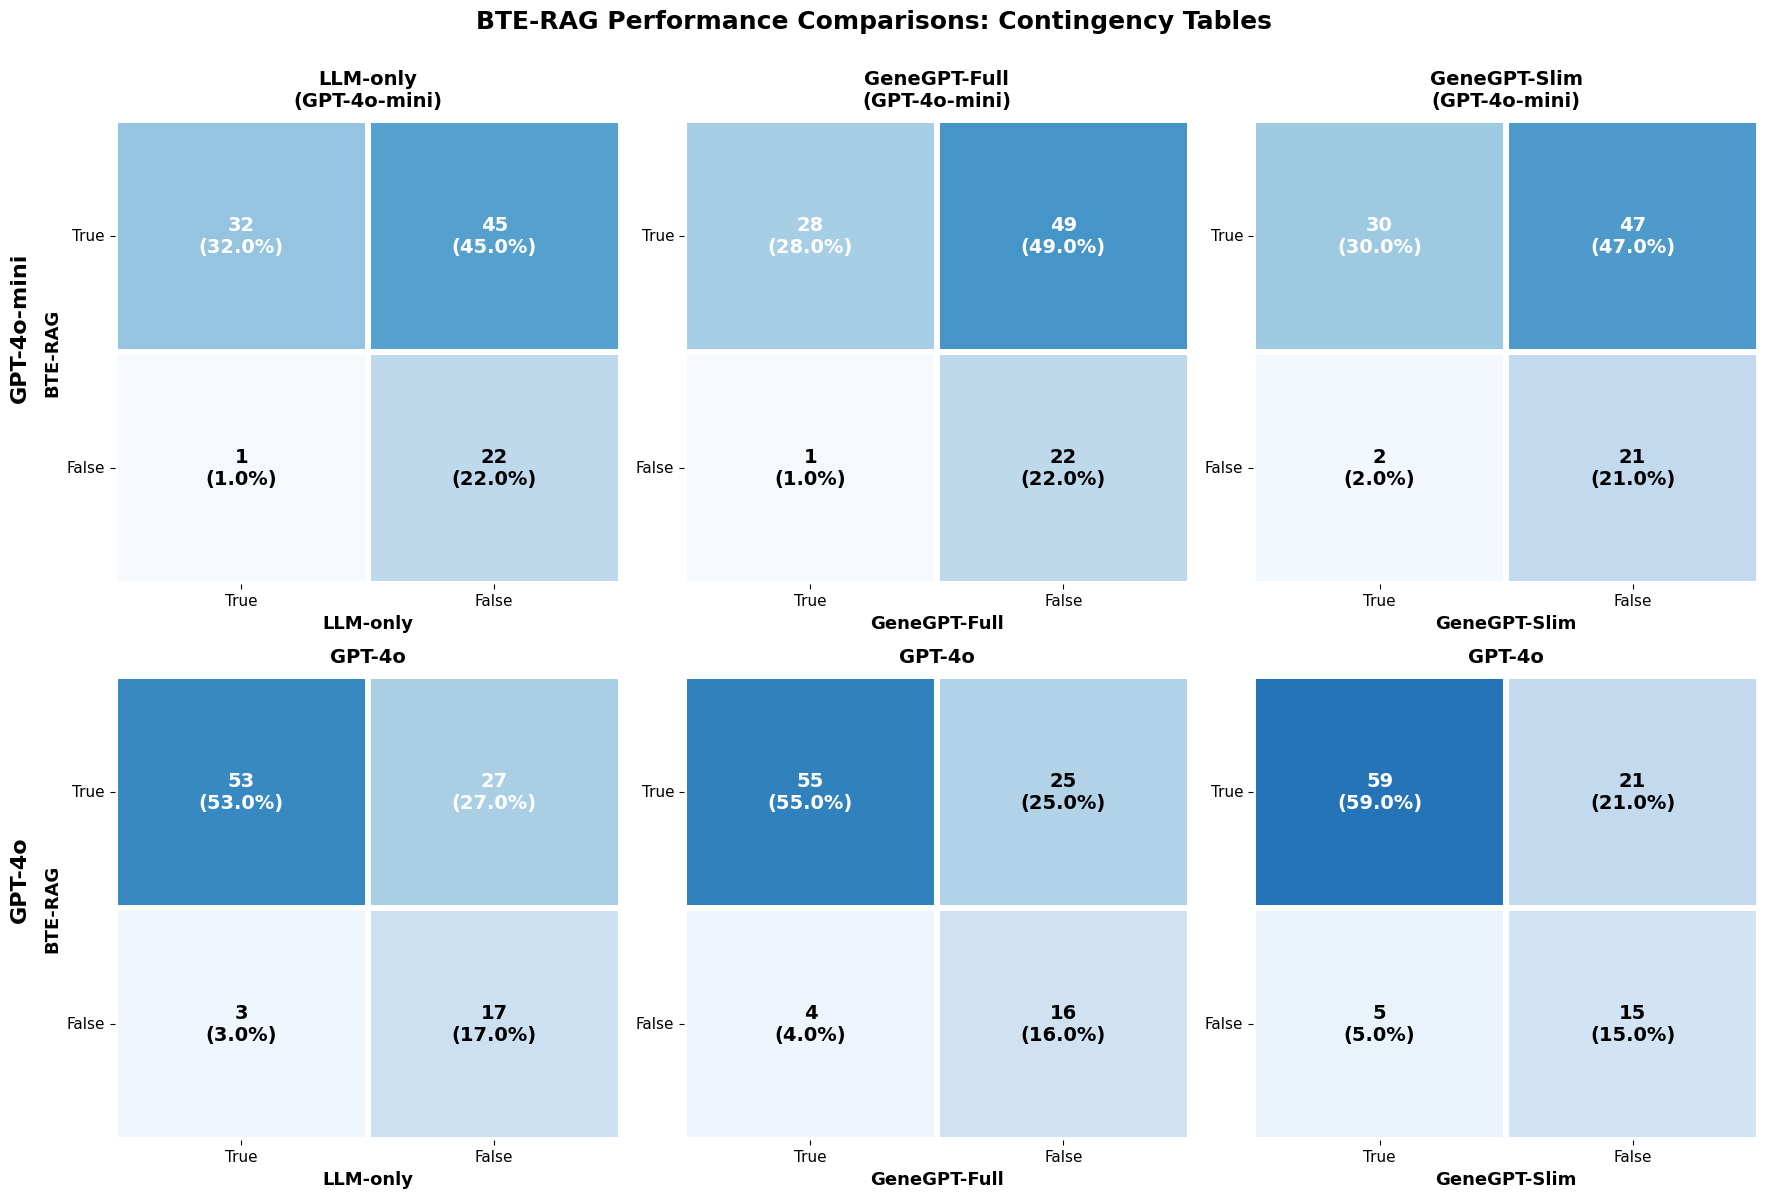


CONTINGENCY TABLE SUMMARY

GPT-4o-mini - BTE-RAG vs LLM-only:
  Both correct: 32 (32.0%)
  BTE-RAG only: 45 (45.0%)
  LLM-only only: 1 (1.0%)
  Both wrong: 22 (22.0%)
  Agreement: 54.0%, Disagreement: 46.0%

GPT-4o-mini - BTE-RAG vs GeneGPT-Full:
  Both correct: 28 (28.0%)
  BTE-RAG only: 49 (49.0%)
  GeneGPT-Full only: 1 (1.0%)
  Both wrong: 22 (22.0%)
  Agreement: 50.0%, Disagreement: 50.0%

GPT-4o-mini - BTE-RAG vs GeneGPT-Slim:
  Both correct: 30 (30.0%)
  BTE-RAG only: 47 (47.0%)
  GeneGPT-Slim only: 2 (2.0%)
  Both wrong: 21 (21.0%)
  Agreement: 51.0%, Disagreement: 49.0%

GPT-4o - BTE-RAG vs LLM-only:
  Both correct: 53 (53.0%)
  BTE-RAG only: 27 (27.0%)
  LLM-only only: 3 (3.0%)
  Both wrong: 17 (17.0%)
  Agreement: 70.0%, Disagreement: 30.0%

GPT-4o - BTE-RAG vs GeneGPT-Full:
  Both correct: 55 (55.0%)
  BTE-RAG only: 25 (25.0%)
  GeneGPT-Full only: 4 (4.0%)
  Both wrong: 16 (16.0%)
  Agreement: 71.0%, Disagreement: 29.0%

GPT-4o - BTE-RAG vs GeneGPT-Slim:
  Both correct: 59 

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_combined_contingency_grid(save_path=None):
    """
    Create a single publication-ready figure with 2x3 contingency table heatmaps
    Rows: GPT-4o-mini (top), GPT-4o (bottom)
    Cols: BTE-RAG vs LLM-only, BTE-RAG vs GeneGPT-Full, BTE-RAG vs GeneGPT-Slim
    """
    
    # Helper function to get correctness values
    def get_correct(df):
        if 'correct' in df.columns:
            return df['correct'].values
        elif 'is_correct' in df.columns:
            return df['is_correct'].values
    
    # Helper function to create contingency table
    def get_contingency(correct1, correct2):
        both_correct = (correct1 & correct2).sum()
        method1_only = (correct1 & ~correct2).sum()
        method2_only = (~correct1 & correct2).sum()
        both_wrong = (~correct1 & ~correct2).sum()
        return np.array([[both_correct, method1_only],
                        [method2_only, both_wrong]])
    
    # Get correctness arrays for GPT-4o-mini
    correct_rag_mini = get_correct(gpt4omini_rag_eval)
    correct_llm_mini = get_correct(gpt4omini_llm_eval)
    correct_full_mini = get_correct(df_full_4omini)
    correct_slim_mini = get_correct(df_slim_4omini)
    
    # Get correctness arrays for GPT-4o
    correct_rag_4o = get_correct(gpt4o_rag_eval)
    correct_llm_4o = get_correct(gpt4o_llm_eval)
    correct_full_4o = get_correct(df_full_4o)
    correct_slim_4o = get_correct(df_slim_4o)
    
    # Create contingency tables
    # Row 1: GPT-4o-mini
    cont_mini_llm = get_contingency(correct_rag_mini, correct_llm_mini)
    cont_mini_full = get_contingency(correct_rag_mini, correct_full_mini)
    cont_mini_slim = get_contingency(correct_rag_mini, correct_slim_mini)
    
    # Row 2: GPT-4o
    cont_4o_llm = get_contingency(correct_rag_4o, correct_llm_4o)
    cont_4o_full = get_contingency(correct_rag_4o, correct_full_4o)
    cont_4o_slim = get_contingency(correct_rag_4o, correct_slim_4o)
    
    # Create figure with 2x3 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Define data for each subplot
    plot_data = [
        # Row 1: GPT-4o-mini
        [(0, 0), cont_mini_llm, 'LLM-only', 'GPT-4o-mini'],
        [(0, 1), cont_mini_full, 'GeneGPT-Full', 'GPT-4o-mini'],
        [(0, 2), cont_mini_slim, 'GeneGPT-Slim', 'GPT-4o-mini'],
        # Row 2: GPT-4o
        [(1, 0), cont_4o_llm, 'LLM-only', 'GPT-4o'],
        [(1, 1), cont_4o_full, 'GeneGPT-Full', 'GPT-4o'],
        [(1, 2), cont_4o_slim, 'GeneGPT-Slim', 'GPT-4o'],
    ]
    
    # Plot each contingency table
    for (row, col), contingency, method2_name, model_name in plot_data:
        ax = axes[row, col]
        
        # Calculate percentages
        total = contingency.sum()
        percentages = (contingency / total * 100)
        
        # Create heatmap
        sns.heatmap(contingency, annot=False, fmt='d', cmap='Blues',
                   cbar=False, linewidths=3, linecolor='white', ax=ax,
                   vmin=0, vmax=80)
        
        # Add custom annotations with counts and percentages
        for i in range(2):
            for j in range(2):
                count = contingency[i, j]
                pct = percentages[i, j]
                text = f'{count}\n({pct:.1f}%)'
                
                # Determine text color based on background
                text_color = 'white' if contingency[i, j] > contingency.max()/2 else 'black'
                
                ax.text(j + 0.5, i + 0.5, text,
                       ha='center', va='center',
                       fontsize=14, fontweight='bold',
                       color=text_color)
        
        # Set labels
        ax.set_xlabel(method2_name, fontsize=13, fontweight='bold')
        
        # Only show y-label on leftmost column
        if col == 0:
            ax.set_ylabel('BTE-RAG', fontsize=13, fontweight='bold')
        else:
            ax.set_ylabel('')
        
        # Set tick labels
        ax.set_xticklabels(['True', 'False'], fontsize=11)
        ax.set_yticklabels(['True', 'False'], fontsize=11, rotation=0)
        
        # Add subplot title (only model name on top row)
        if row == 0:
            ax.set_title(f'{method2_name}\n({model_name})', 
                        fontsize=14, fontweight='bold', pad=10)
        else:
            ax.set_title(f'{model_name}', 
                        fontsize=14, fontweight='bold', pad=10)
    
    # Add overall title
    fig.suptitle('BTE-RAG Performance Comparisons: Contingency Tables', 
                fontsize=18, fontweight='bold', y=0.995)
    
    # Add row labels on the left
    fig.text(0.02, 0.73, 'GPT-4o-mini', fontsize=16, fontweight='bold', 
            rotation=90, va='center')
    fig.text(0.02, 0.27, 'GPT-4o', fontsize=16, fontweight='bold', 
            rotation=90, va='center')
    
    plt.tight_layout(rect=[0.03, 0, 1, 0.99])
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*80)
    print("CONTINGENCY TABLE SUMMARY")
    print("="*80)
    
    comparisons = [
        ("GPT-4o-mini", "LLM-only", cont_mini_llm),
        ("GPT-4o-mini", "GeneGPT-Full", cont_mini_full),
        ("GPT-4o-mini", "GeneGPT-Slim", cont_mini_slim),
        ("GPT-4o", "LLM-only", cont_4o_llm),
        ("GPT-4o", "GeneGPT-Full", cont_4o_full),
        ("GPT-4o", "GeneGPT-Slim", cont_4o_slim),
    ]
    
    for model, method2, cont in comparisons:
        both_correct = cont[0, 0]
        bte_only = cont[0, 1]
        method2_only = cont[1, 0]
        both_wrong = cont[1, 1]
        total = cont.sum()
        
        agreement = (both_correct + both_wrong) / total * 100
        disagreement = (bte_only + method2_only) / total * 100
        
        print(f"\n{model} - BTE-RAG vs {method2}:")
        print(f"  Both correct: {both_correct} ({both_correct/total*100:.1f}%)")
        print(f"  BTE-RAG only: {bte_only} ({bte_only/total*100:.1f}%)")
        print(f"  {method2} only: {method2_only} ({method2_only/total*100:.1f}%)")
        print(f"  Both wrong: {both_wrong} ({both_wrong/total*100:.1f}%)")
        print(f"  Agreement: {agreement:.1f}%, Disagreement: {disagreement:.1f}%")
    
    print("\n" + "="*80 + "\n")


# Create the combined plot
plot_combined_contingency_grid(save_path= 'figures/geneTuring_gene_disease/combined_contingency_tables.png')

# Or just display without saving
# plot_combined_contingency_grid()
